# IMC Prosperity Round 3 — Log Analysis & Strategy Notebook

This notebook is rewritten for **Round 3** and focuses on the actual products in this round:

- `HYDROGEL_PACK`
- `VELVETFRUIT_EXTRACT`
- `VEV_4000` … `VEV_6500` vouchers

It keeps the original logger-analysis spirit, but adapts everything to the Round 3 structure:
spot fair value, order-book imbalance, adverse selection, fill toxicity, PnL / drawdown, and
most importantly the **options smile / strike-by-strike analysis** needed for voucher strategy design.

## 0 — Configuration & Imports

In [39]:
# ─── USER SETTINGS ────────────────────────────────────────────────────────────
LOG_PATH  = "algorithm/log output/v21.json"   # Prosperity log file
JSON_PATH = "algorithm/log output/v21.json"   # Result JSON file

# You can also point these to a single run you want to inspect.
# Example:
# LOG_PATH  = "algorithm/log output/v20.json"
# JSON_PATH = "algorithm/log output/v20.json"

# ──────────────────────────────────────────────────────────────────────────────
import json
import re
import warnings
from io import StringIO
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)

C = {
    "bg": "#0d1117",
    "fg": "#c9d1d9",
    "grid": "#30363d",
    "spot": "#58a6ff",
    "alpha": "#2ea043",
    "theta": "#f85149",
    "ema": "#d2a8ff",
    "drawdown": "#ff7b72",
    "buy": "#2ecc71",
    "sell": "#ff6b6b",
    "mid": "#f0f6fc",
    "micro": "#e74c3c",
    "pressure": "#79c0ff",
}

ROUND_NAME = "Round 3"
TICKS_PER_DAY = 1_000_000
TTE_START_DAYS = 5.0
TRADING_DAYS = 252.0

SPOT_PRODUCTS = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
VOUCHER_PRODUCTS = [f"VEV_{k}" for k in [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]]
CORE_VOUCHERS = ["VEV_4000", "VEV_4500", "VEV_5000", "VEV_5200", "VEV_5300", "VEV_5400"]

## 1 — Parse Log Files

In [40]:
def read_maybe_json(path: str):
    """
    Prosperity log artifacts are sometimes JSON, sometimes text.
    This helper tries JSON first and falls back to raw text.
    """
    path_obj = Path(path)
    with path_obj.open("r", encoding="utf-8") as f:
        raw = f.read()

    try:
        return json.loads(raw)
    except Exception:
        return raw


def load_semicolon_table(raw):
    """
    Parse semicolon-delimited activities logs or similar text dumps.
    Returns an empty dataframe if parsing fails.
    """
    if raw is None:
        return pd.DataFrame()

    if isinstance(raw, pd.DataFrame):
        return raw.copy()

    if isinstance(raw, list):
        if len(raw) == 0:
            return pd.DataFrame()
        # If it is already list-of-dicts
        if isinstance(raw[0], dict):
            return pd.DataFrame(raw)
        # If it is list of raw lines
        raw = "\n".join(str(x) for x in raw)

    if isinstance(raw, str):
        txt = raw.strip()
        if not txt:
            return pd.DataFrame()

        # Most Prosperity logs use semicolon-separated CSV-like text.
        for sep in [";", ",", "\t"]:
            try:
                df = pd.read_csv(StringIO(txt), sep=sep)
                if len(df.columns) > 1:
                    return df
            except Exception:
                pass

        # If there is a JSON string inside the field
        try:
            obj = json.loads(txt)
            if isinstance(obj, list):
                return pd.DataFrame(obj)
            if isinstance(obj, dict):
                return pd.DataFrame([obj])
        except Exception:
            pass

    return pd.DataFrame()


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out


log_raw = read_maybe_json(LOG_PATH)
json_raw = read_maybe_json(JSON_PATH)

# Try to find the key payloads in a flexible way.
# Common Prosperity keys: activitiesLog, tradeHistory, traderData, logs / log, etc.
if isinstance(json_raw, dict):
    result_profit = json_raw.get("profit", json_raw.get("total_profit", 0.0))
    raw_activities = json_raw.get("activitiesLog", json_raw.get("activityLog", json_raw.get("log", json_raw.get("logs", []))))
    raw_trades = json_raw.get("tradeHistory", json_raw.get("trades", []))
else:
    result_profit = 0.0
    raw_activities = []
    raw_trades = []

# Prefer any activity payload found in LOG_PATH if it looks more complete.
if isinstance(log_raw, dict):
    raw_activities = log_raw.get("activitiesLog", raw_activities)
    raw_trades = log_raw.get("tradeHistory", raw_trades)

print(f"Result profit reported by JSON: {result_profit:,.4f}")

activities = normalize_columns(load_semicolon_table(raw_activities))
trades = normalize_columns(load_semicolon_table(raw_trades))

print(f"Activities rows: {len(activities):,}")
print(f"Trade rows     : {len(trades):,}")

display(activities.head(3))
display(trades.head(3))

Result profit reported by JSON: 15,369.8334
Activities rows: 12,000
Trade rows     : 0


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,VEV_5200,102,21,NaN,NaN,NaN,NaN,106,21,NaN,NaN,NaN,NaN,104.0,0.0
1,2,0,VEV_5300,52,20,NaN,NaN,NaN,NaN,54,20,NaN,NaN,NaN,NaN,53.0,0.0
2,2,0,VEV_5000,267,7,266.0,14.0,NaN,NaN,273,7,274.0,14.0,NaN,NaN,270.0,0.0


""


## 1a — Parse trader logs / quote traces if available

In [41]:
def parse_lambda_log_frame(df: pd.DataFrame, products: list[str]) -> pd.DataFrame:
    """
    Parse strategy debug traces if the log includes a `lambdaLog` column.
    The parser is intentionally tolerant:
    it looks for patterns like `PROD ... EMA=... FV=... pos=... bid=... ask=... size=... skew=...`
    """
    if df.empty or "lambdaLog" not in df.columns:
        return pd.DataFrame()

    rows = []
    for _, row in df.iterrows():
        ll = str(row.get("lambdaLog", ""))
        if not ll or ll == "nan":
            continue
        rec = {"timestamp": row.get("timestamp", np.nan)}
        for prod in products:
            pat = re.escape(prod)
            m_ema  = re.search(rf"{pat}.*?EMA=([-\d.]+)", ll)
            m_fv   = re.search(rf"{pat}.*?FV=([-\d.]+)", ll)
            m_pos  = re.search(rf"{pat}.*?pos=(-?\d+)", ll)
            m_bid  = re.search(rf"{pat}.*?bid=(\d+)", ll)
            m_ask  = re.search(rf"{pat}.*?ask=(\d+)", ll)
            m_size = re.search(rf"{pat}.*?size=(\d+)", ll)
            m_skew = re.search(rf"{pat}.*?skew=(-?\d+)", ll)

            rec[f"{prod}_fv"]   = float(m_ema.group(1)) if m_ema else (float(m_fv.group(1)) if m_fv else np.nan)
            rec[f"{prod}_pos"]  = int(m_pos.group(1)) if m_pos else np.nan
            rec[f"{prod}_bid"]  = int(m_bid.group(1)) if m_bid else np.nan
            rec[f"{prod}_ask"]  = int(m_ask.group(1)) if m_ask else np.nan
            rec[f"{prod}_size"] = int(m_size.group(1)) if m_size else np.nan
            rec[f"{prod}_skew"] = int(m_skew.group(1)) if m_skew else np.nan
        rows.append(rec)

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
    return out


parsed_logs = parse_lambda_log_frame(activities, SPOT_PRODUCTS + VOUCHER_PRODUCTS)
print("Parsed strategy debug rows:", len(parsed_logs))
display(parsed_logs.head(3))

Parsed strategy debug rows: 0


""


## 1b — Parse trade history & classify our trades

In [42]:
def normalize_trade_history(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df

    out = df.copy()

    # Common Prosperity keys
    rename_map = {}
    for a, b in [("symbol", "symbol"), ("product", "symbol"), ("price", "price"), ("quantity", "quantity"),
                 ("buyer", "buyer"), ("seller", "seller"), ("timestamp", "timestamp"), ("trade_id", "trade_id")]:
        if a in out.columns:
            rename_map[a] = b
    out = out.rename(columns=rename_map)

    # Standardize
    for c in ["timestamp", "price", "quantity"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    if "buyer" in out.columns and "seller" in out.columns:
        out["is_buy_sub"] = out["buyer"].astype(str).eq("SUBMISSION")
        out["is_sell_sub"] = out["seller"].astype(str).eq("SUBMISSION")
        out["is_our_trade"] = out["is_buy_sub"] | out["is_sell_sub"]
        out["side"] = np.where(out["is_buy_sub"], "BUY", np.where(out["is_sell_sub"], "SELL", "OTHER"))
    else:
        out["is_our_trade"] = False
        out["side"] = "OTHER"

    if "quantity" in out.columns:
        out["abs_qty"] = out["quantity"].abs()
    else:
        out["abs_qty"] = np.nan

    return out


trades = normalize_trade_history(trades)
our_trades = trades[trades.get("is_our_trade", False)].copy() if not trades.empty else pd.DataFrame()
print("Our trades rows:", len(our_trades))
display(our_trades.head(5))

Our trades rows: 0


""


## 2 — Build per-product market dataframes

In [43]:
def coerce_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def weighted_mid_from_book(df: pd.DataFrame) -> pd.Series:
    bid_px = df["bid_price_1"]
    ask_px = df["ask_price_1"]
    bid_q  = df.get("bid_volume_1", pd.Series(np.nan, index=df.index)).fillna(1).abs()
    ask_q  = df.get("ask_volume_1", pd.Series(np.nan, index=df.index)).fillna(1).abs()
    denom  = (bid_q + ask_q).replace(0, np.nan)
    return (bid_px * ask_q + ask_px * bid_q) / denom


def top_depth(df: pd.DataFrame, side: str) -> pd.Series:
    if side == "bid":
        cols = [c for c in df.columns if c.startswith("bid_volume_")]
    else:
        cols = [c for c in df.columns if c.startswith("ask_volume_")]
    if not cols:
        return pd.Series(np.nan, index=df.index)
    arr = sum(df[c].fillna(0).abs() for c in cols)
    return arr


def build_product_frames(market_df: pd.DataFrame, parsed_logs_df: pd.DataFrame, trades_df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    if market_df.empty:
        return {}

    product_col = "product" if "product" in market_df.columns else ("symbol" if "symbol" in market_df.columns else None)
    if product_col is None:
        raise ValueError("Could not find a product/symbol column in activities data")

    market_df = normalize_columns(market_df.copy())
    market_df = coerce_numeric(
        market_df,
        ["day", "timestamp", "bid_price_1", "bid_volume_1", "bid_price_2", "bid_volume_2", "bid_price_3", "bid_volume_3",
         "ask_price_1", "ask_volume_1", "ask_price_2", "ask_volume_2", "ask_price_3", "ask_volume_3",
         "mid_price", "profit_and_loss"]
    )

    frames = {}
    products = sorted(market_df[product_col].dropna().astype(str).unique().tolist())

    for p in products:
        df = market_df[market_df[product_col].astype(str) == p].copy().reset_index(drop=True)
        if df.empty:
            continue

        # Numerical normalization
        for c in df.columns:
            if any(k in c for k in ["price", "volume", "mid", "profit", "pnl", "timestamp", "day"]):
                df[c] = pd.to_numeric(df[c], errors="coerce")

        # Core book fields
        df["spread"] = df["ask_price_1"] - df["bid_price_1"]
        df["mid_price"] = df["mid_price"] if "mid_price" in df.columns else (df["bid_price_1"] + df["ask_price_1"]) / 2.0
        df["wall_mid"] = weighted_mid_from_book(df)
        df["microprice"] = df["wall_mid"]  # same top-of-book weighted mid, but kept separate for naming
        df["bid_depth"] = top_depth(df, "bid")
        df["ask_depth"] = top_depth(df, "ask")
        df["imbalance"] = (df["bid_depth"] - df["ask_depth"]) / (df["bid_depth"] + df["ask_depth"]).replace(0, np.nan)
        df["imbalance"] = df["imbalance"].fillna(0.0)

        # Returns / dynamics
        df["mid_chg"] = df["mid_price"].diff()
        df["mid_ret"] = df["mid_price"].pct_change()
        df["log_ret"] = np.log(df["mid_price"].replace(0, np.nan)).diff()
        df["abs_mid_chg"] = df["mid_chg"].abs()
        df["vol_20"] = df["mid_chg"].rolling(20, min_periods=5).std()
        df["vol_50"] = df["mid_chg"].rolling(50, min_periods=10).std()
        df["trend_5"] = df["mid_price"].diff(5)
        df["trend_20"] = df["mid_price"].diff(20)
        df["trend_fast"] = df["mid_price"].ewm(span=10, adjust=False).mean()
        df["trend_slow"] = df["mid_price"].ewm(span=40, adjust=False).mean()
        df["trend_gap"] = df["trend_fast"] - df["trend_slow"]

        # PnL / drawdown if present
        if "profit_and_loss" in df.columns:
            df["pnl"] = pd.to_numeric(df["profit_and_loss"], errors="coerce")
            df["pnl_chg"] = df["pnl"].diff().fillna(df["pnl"])
            df["running_max"] = df["pnl"].cummax()
            df["drawdown"] = df["running_max"] - df["pnl"]
        else:
            df["pnl"] = np.nan
            df["pnl_chg"] = np.nan
            df["running_max"] = np.nan
            df["drawdown"] = np.nan

        # Optional merge of parsed logger fields (FV / bid / ask / skew / pos)
        if not parsed_logs_df.empty and "timestamp" in parsed_logs_df.columns:
            merge_cols = [c for c in parsed_logs_df.columns if c.startswith(f"{p}_")] + ["timestamp"]
            if len(merge_cols) > 1:
                df = df.merge(parsed_logs_df[merge_cols].rename(columns={"timestamp": "timestamp"}),
                              on="timestamp", how="left")

        # Optional merge of our trade count at each timestamp
        if not trades_df.empty and "symbol" in trades_df.columns and "timestamp" in trades_df.columns:
            my_t = trades_df[trades_df["is_our_trade"] & (trades_df["symbol"].astype(str) == p)]
            if not my_t.empty:
                ts_counts = my_t.groupby("timestamp").agg(
                    our_trade_qty=("abs_qty", "sum"),
                    our_trade_count=("abs_qty", "size"),
                    our_buy_qty=("abs_qty", lambda s: s[my_t.loc[s.index, "side"].eq("BUY")].sum() if len(s) else 0),
                )
                df = df.merge(ts_counts, left_on="timestamp", right_index=True, how="left")

        frames[p] = df

    return frames


mkt = build_product_frames(activities, parsed_logs, trades)
products = list(mkt.keys())
spot_products = [p for p in SPOT_PRODUCTS if p in products]
voucher_products = [p for p in VOUCHER_PRODUCTS if p in products]

print("Detected products:", products)
print("Spot products   :", spot_products)
print("Vouchers        :", voucher_products[:10])
for p in products[:5]:
    print(f"{p}: {len(mkt[p]):,} rows")

Detected products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Spot products   : ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']
Vouchers        : ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
HYDROGEL_PACK: 1,000 rows
VELVETFRUIT_EXTRACT: 1,000 rows
VEV_4000: 1,000 rows
VEV_4500: 1,000 rows
VEV_5000: 1,000 rows


## 2a — Round 3 product map & quick cross-section

In [44]:
product_summary = []
for p, df in mkt.items():
    rec = {
        "product": p,
        "rows": len(df),
        "mean_spread": df["spread"].mean(),
        "median_spread": df["spread"].median(),
        "mean_mid": df["mid_price"].mean(),
        "final_pnl": df["pnl"].iloc[-1] if "pnl" in df.columns and df["pnl"].notna().any() else np.nan,
        "vol_20": df["vol_20"].mean(),
        "imbalance_mean": df["imbalance"].mean(),
    }
    if "pnl" in df.columns and df["pnl"].notna().any():
        series = df["pnl"].fillna(method="ffill").fillna(0)
        peak = series.cummax()
        dd = peak - series
        rec["max_drawdown"] = dd.max()
        rec["recovery_ratio"] = (series.iloc[-1] / dd.max()) if dd.max() > 1e-9 else np.nan
    product_summary.append(rec)

summary_df = pd.DataFrame(product_summary).sort_values(["final_pnl"], ascending=False)
display(summary_df)

,product,rows,mean_spread,median_spread,mean_mid,final_pnl,vol_20,imbalance_mean,max_drawdown,recovery_ratio
0,HYDROGEL_PACK,1000,15.645,16.0,9979.2935,11520.000000,2.250686,-0.000972,11657.625000,0.988194
1,VELVETFRUIT_EXTRACT,1000,4.983,5.0,5262.3785,2269.906250,1.147980,0.000456,2688.500000,0.844302
5,VEV_5100,1000,4.444,4.0,174.7820,1172.292969,0.843855,-0.000003,8644.433594,0.135612
4,VEV_5000,1000,6.231,6.0,265.5945,238.609375,0.977566,-0.000003,4075.176758,0.058552
7,VEV_5300,1000,2.171,2.0,50.0555,183.583008,0.504833,0.000032,4106.527344,0.044705
8,VEV_5400,1000,1.419,1.0,16.0195,50.876099,0.276522,-0.000042,154.547455,0.329194
11,VEV_6500,1000,1.000,1.0,0.5000,0.000000,0.000000,-0.000226,0.000000,NaN
10,VEV_6000,1000,1.000,1.0,0.5000,0.000000,0.000000,-0.000071,0.000000,NaN
3,VEV_4500,1000,16.081,16.0,762.3895,-2.690430,1.212835,-0.000003,149.695312,-0.017973
2,VEV_4000,1000,20.973,21.0,1262.3905,-2.690430,1.357468,0.000052,149.695312,-0.017973


## 3 — Universal product dashboard

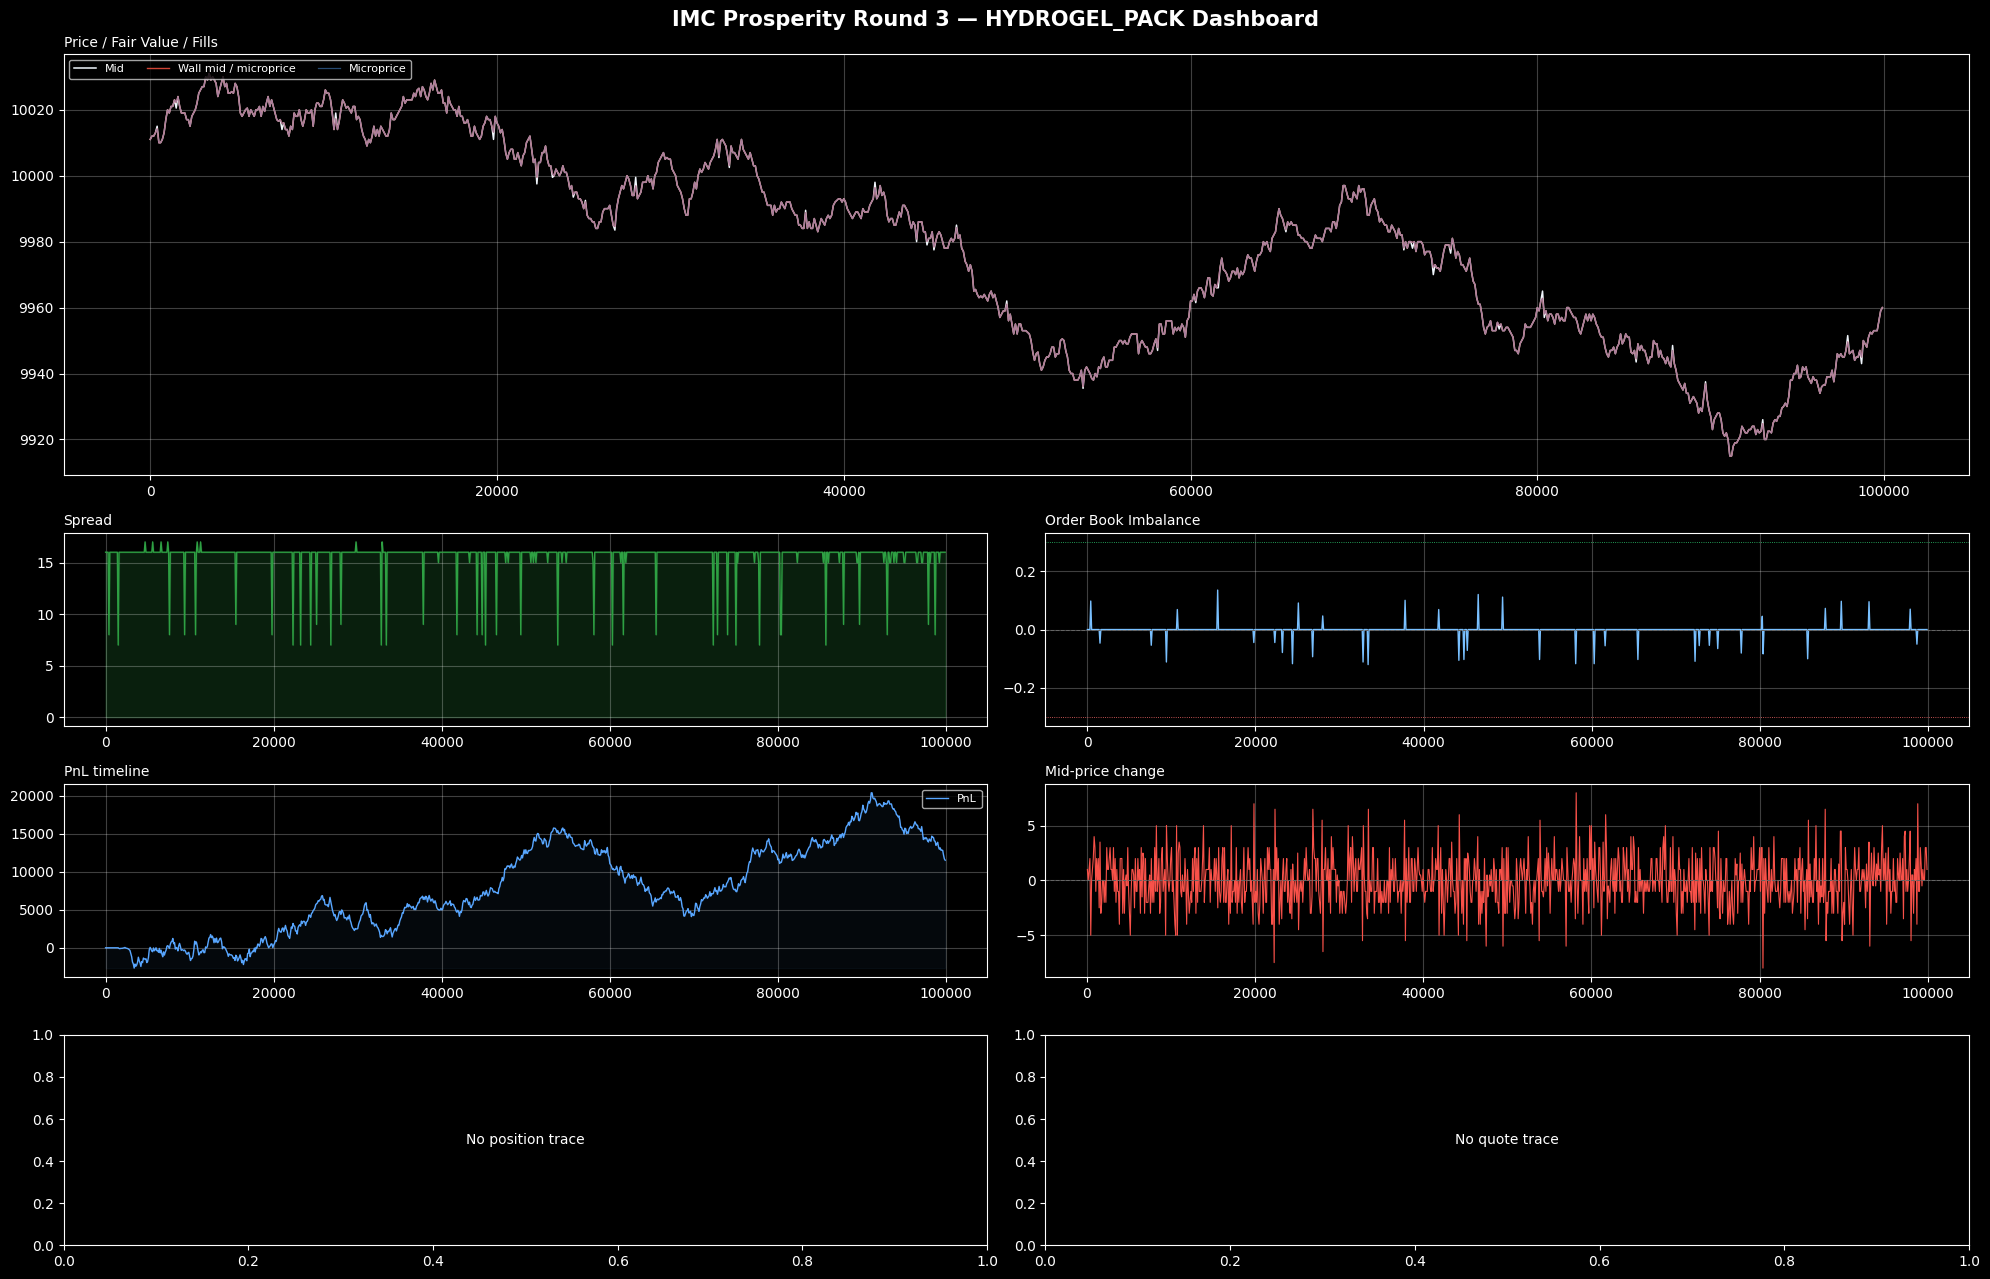

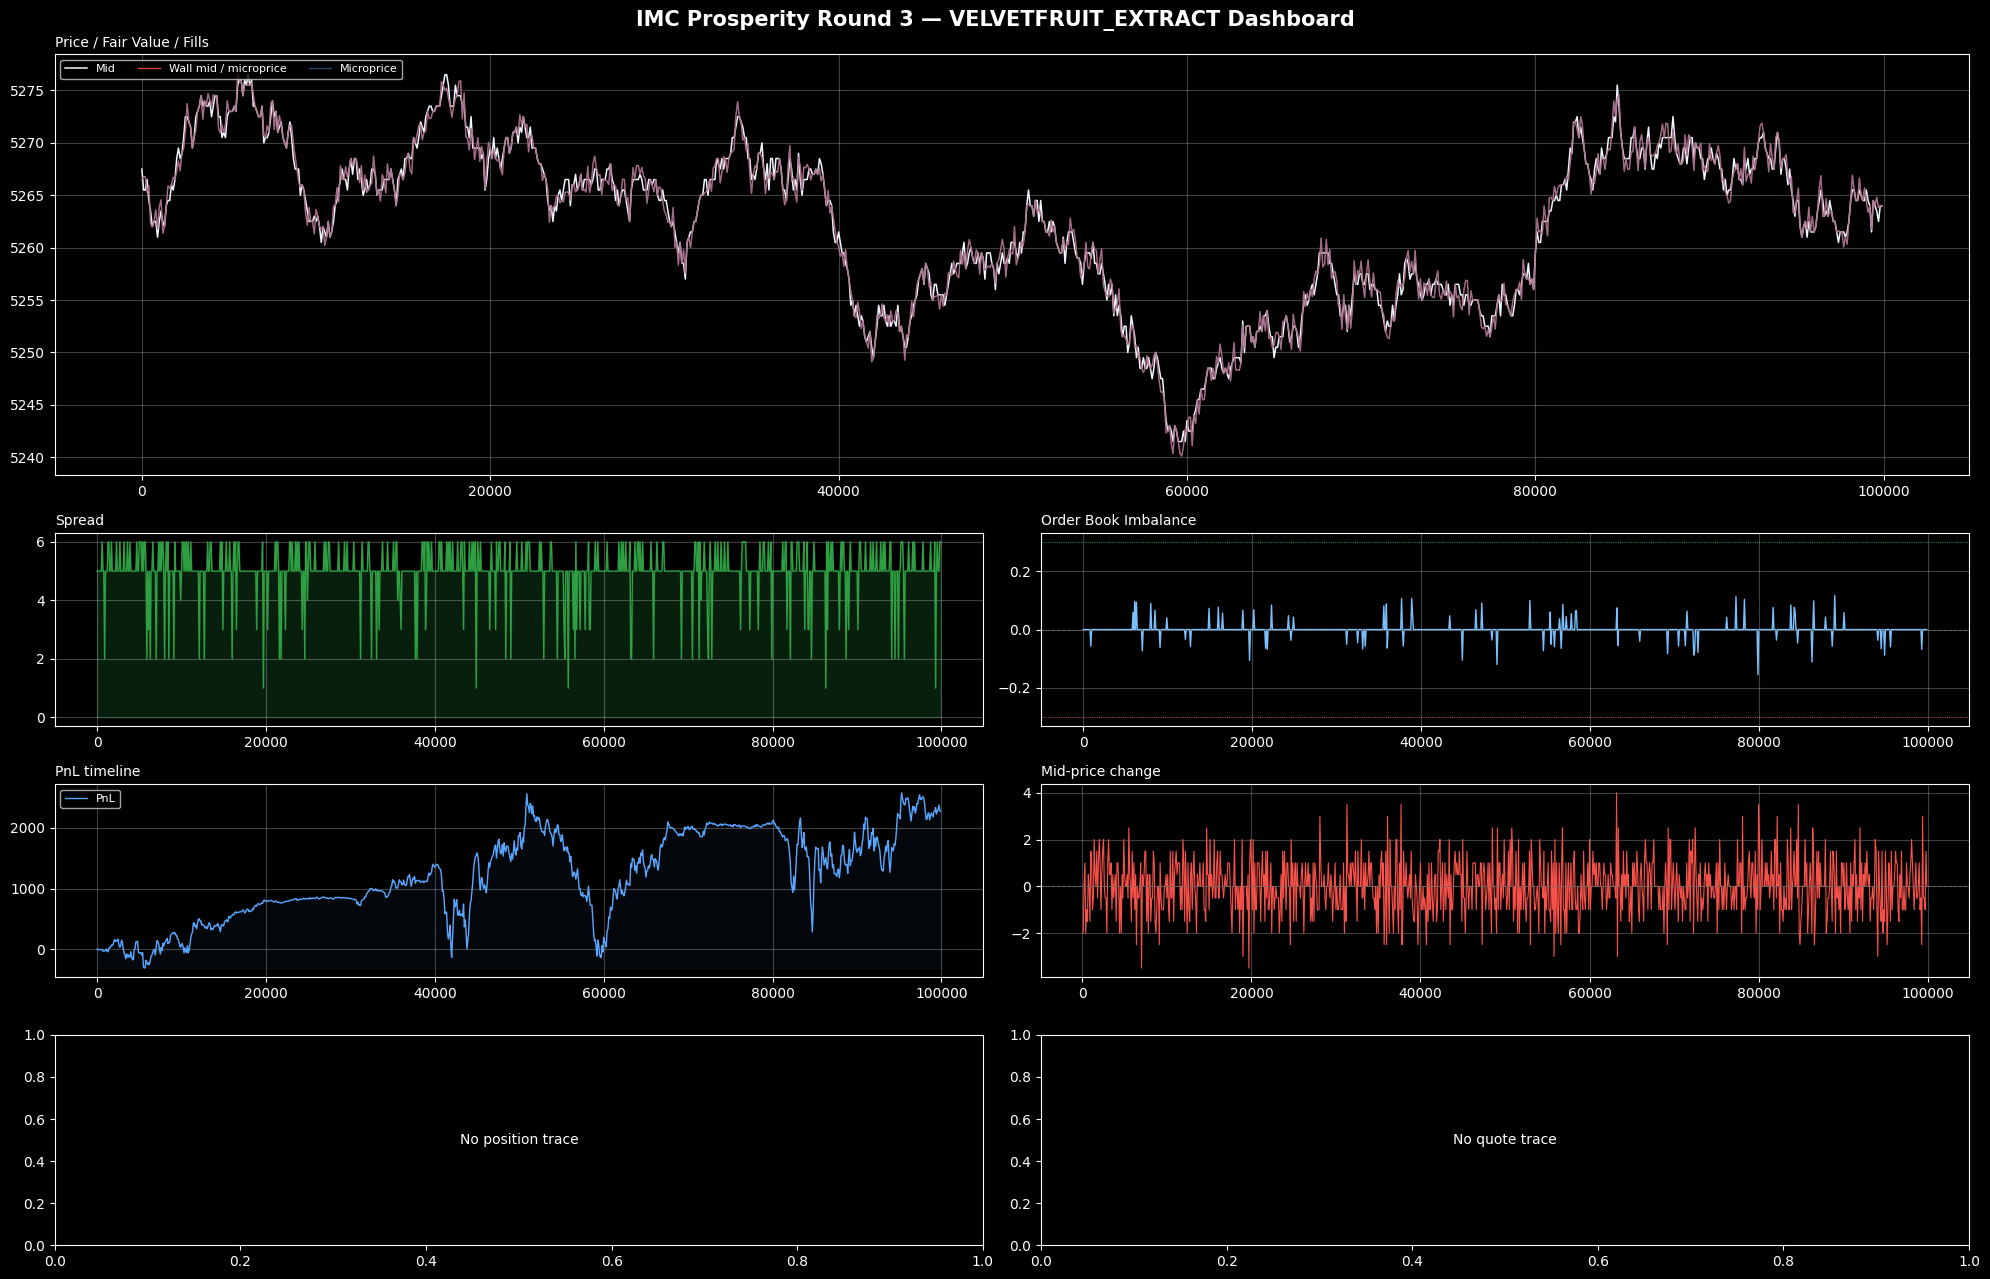

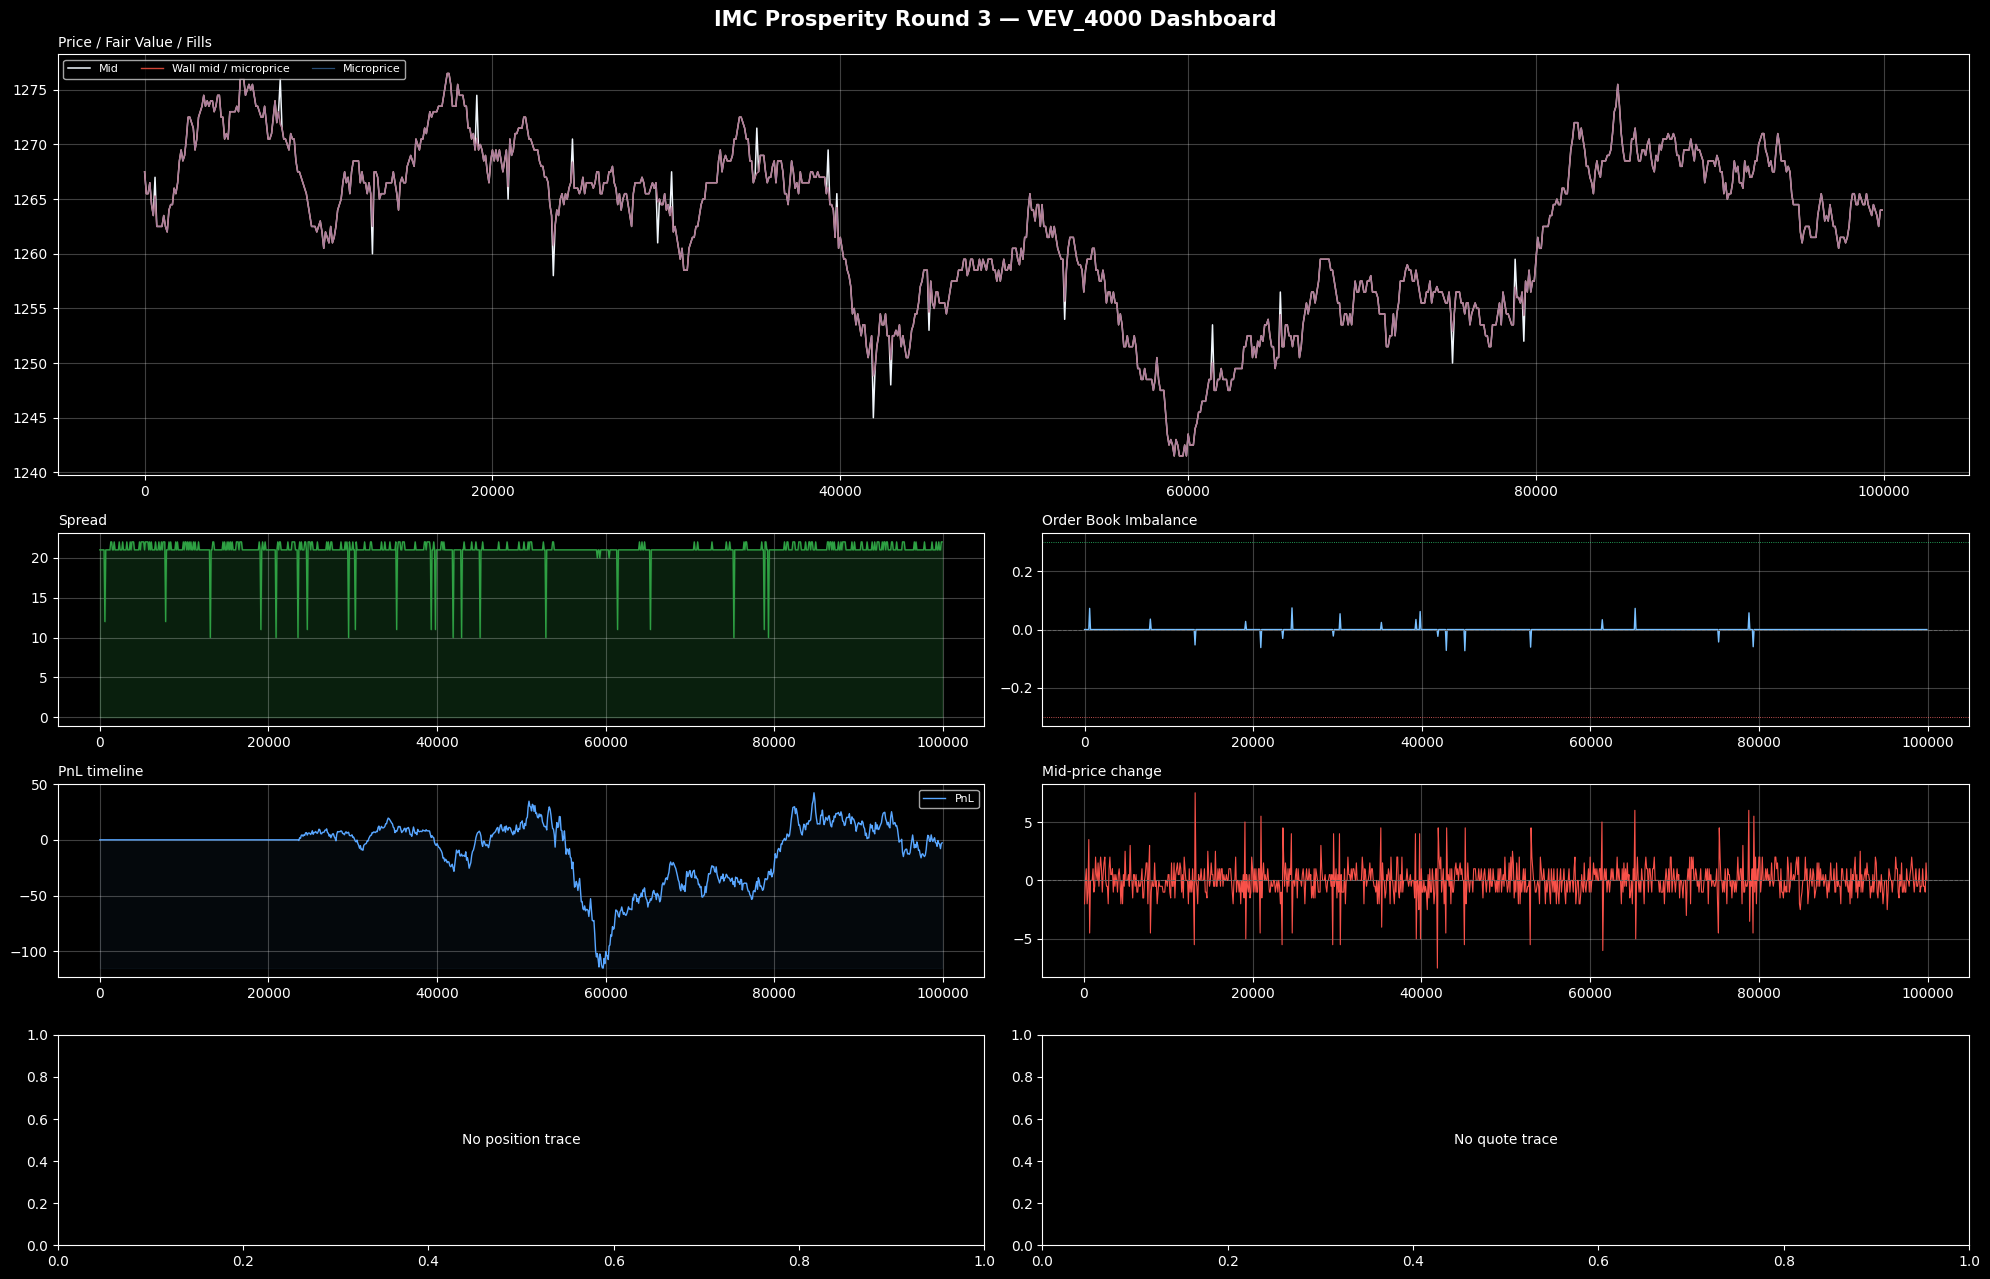

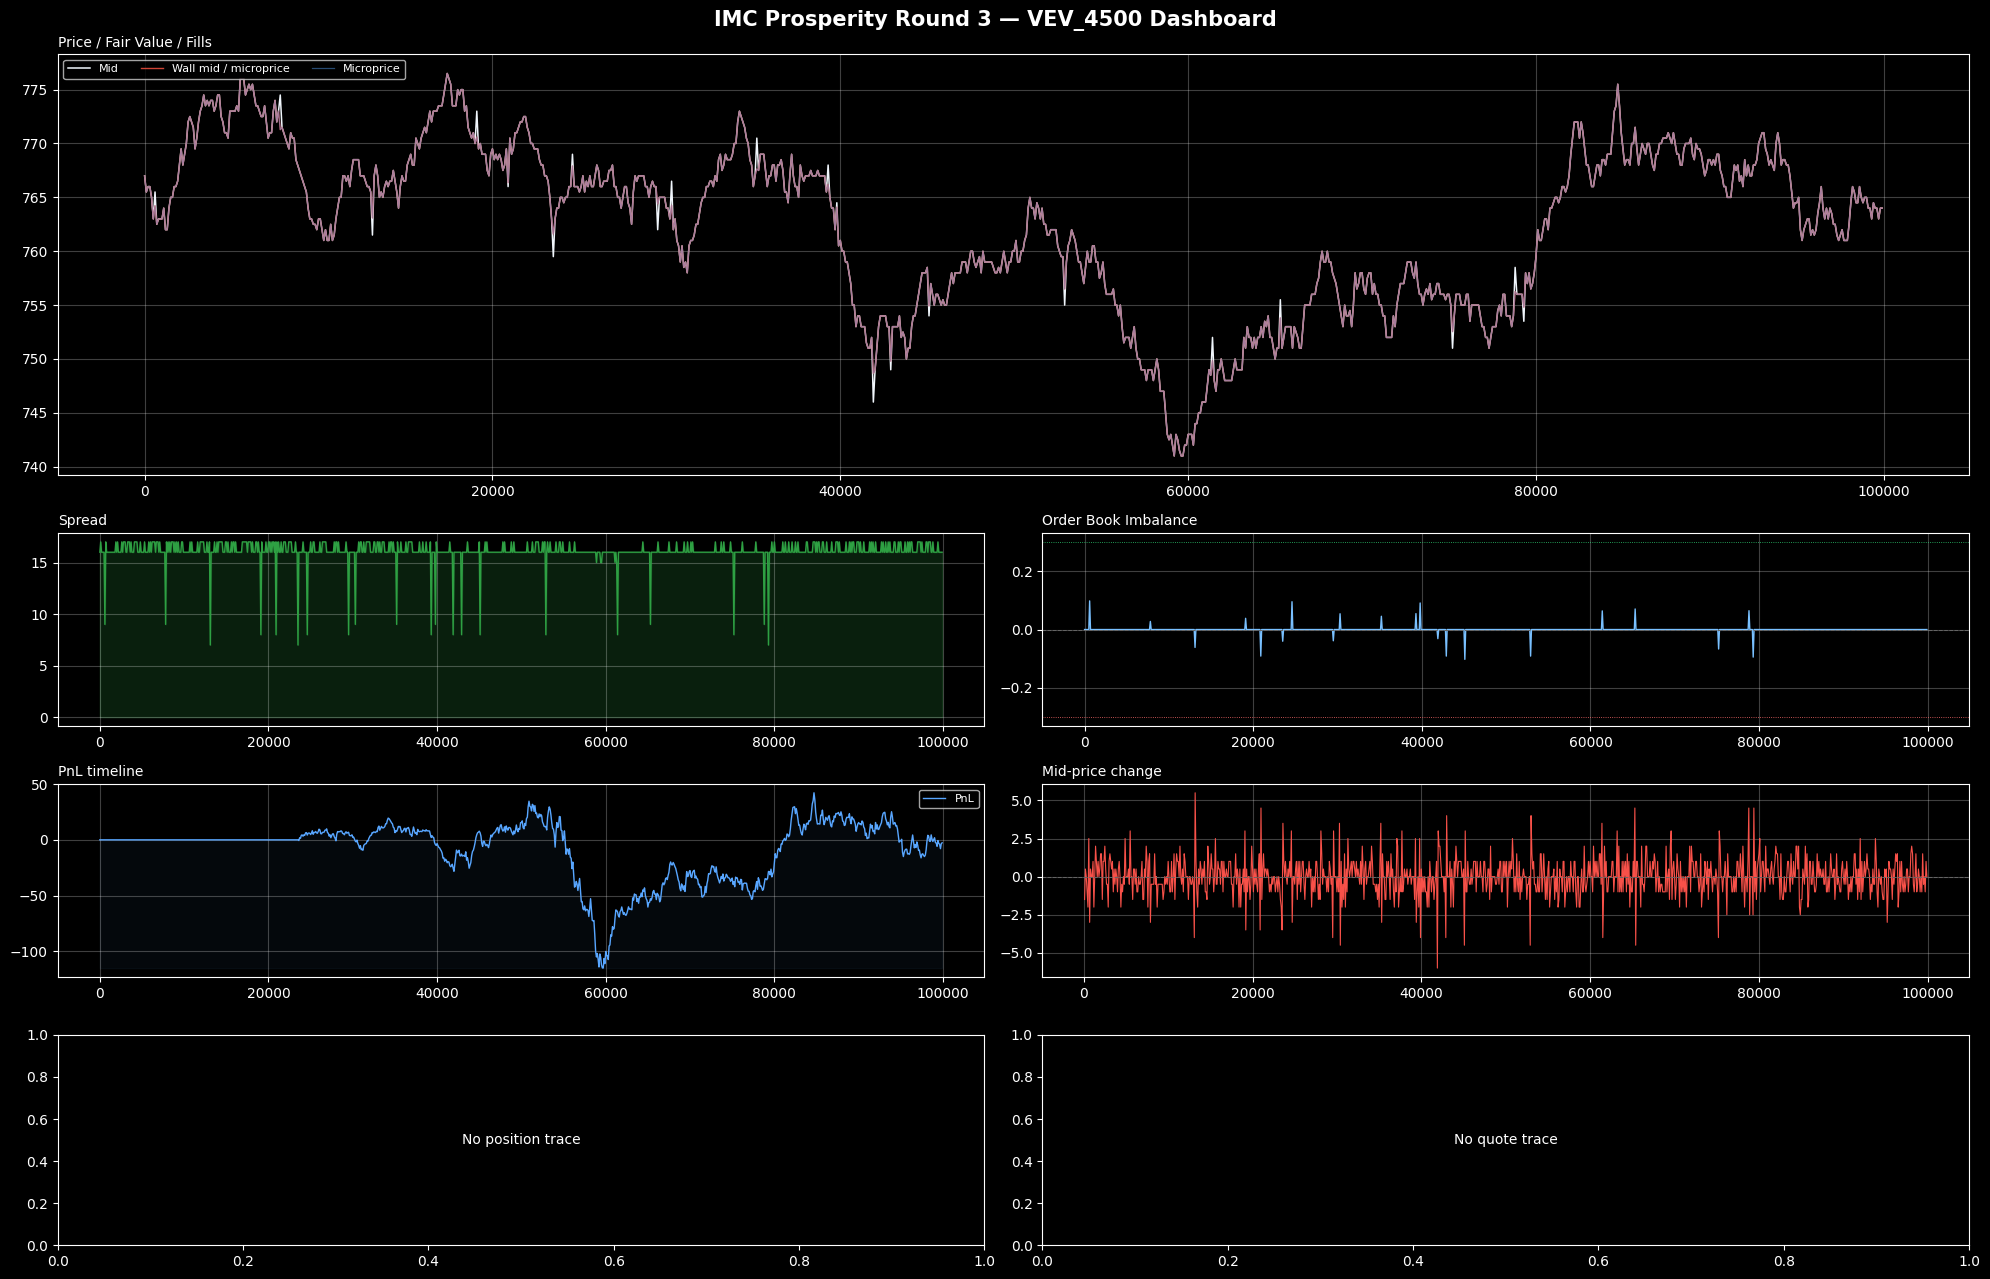

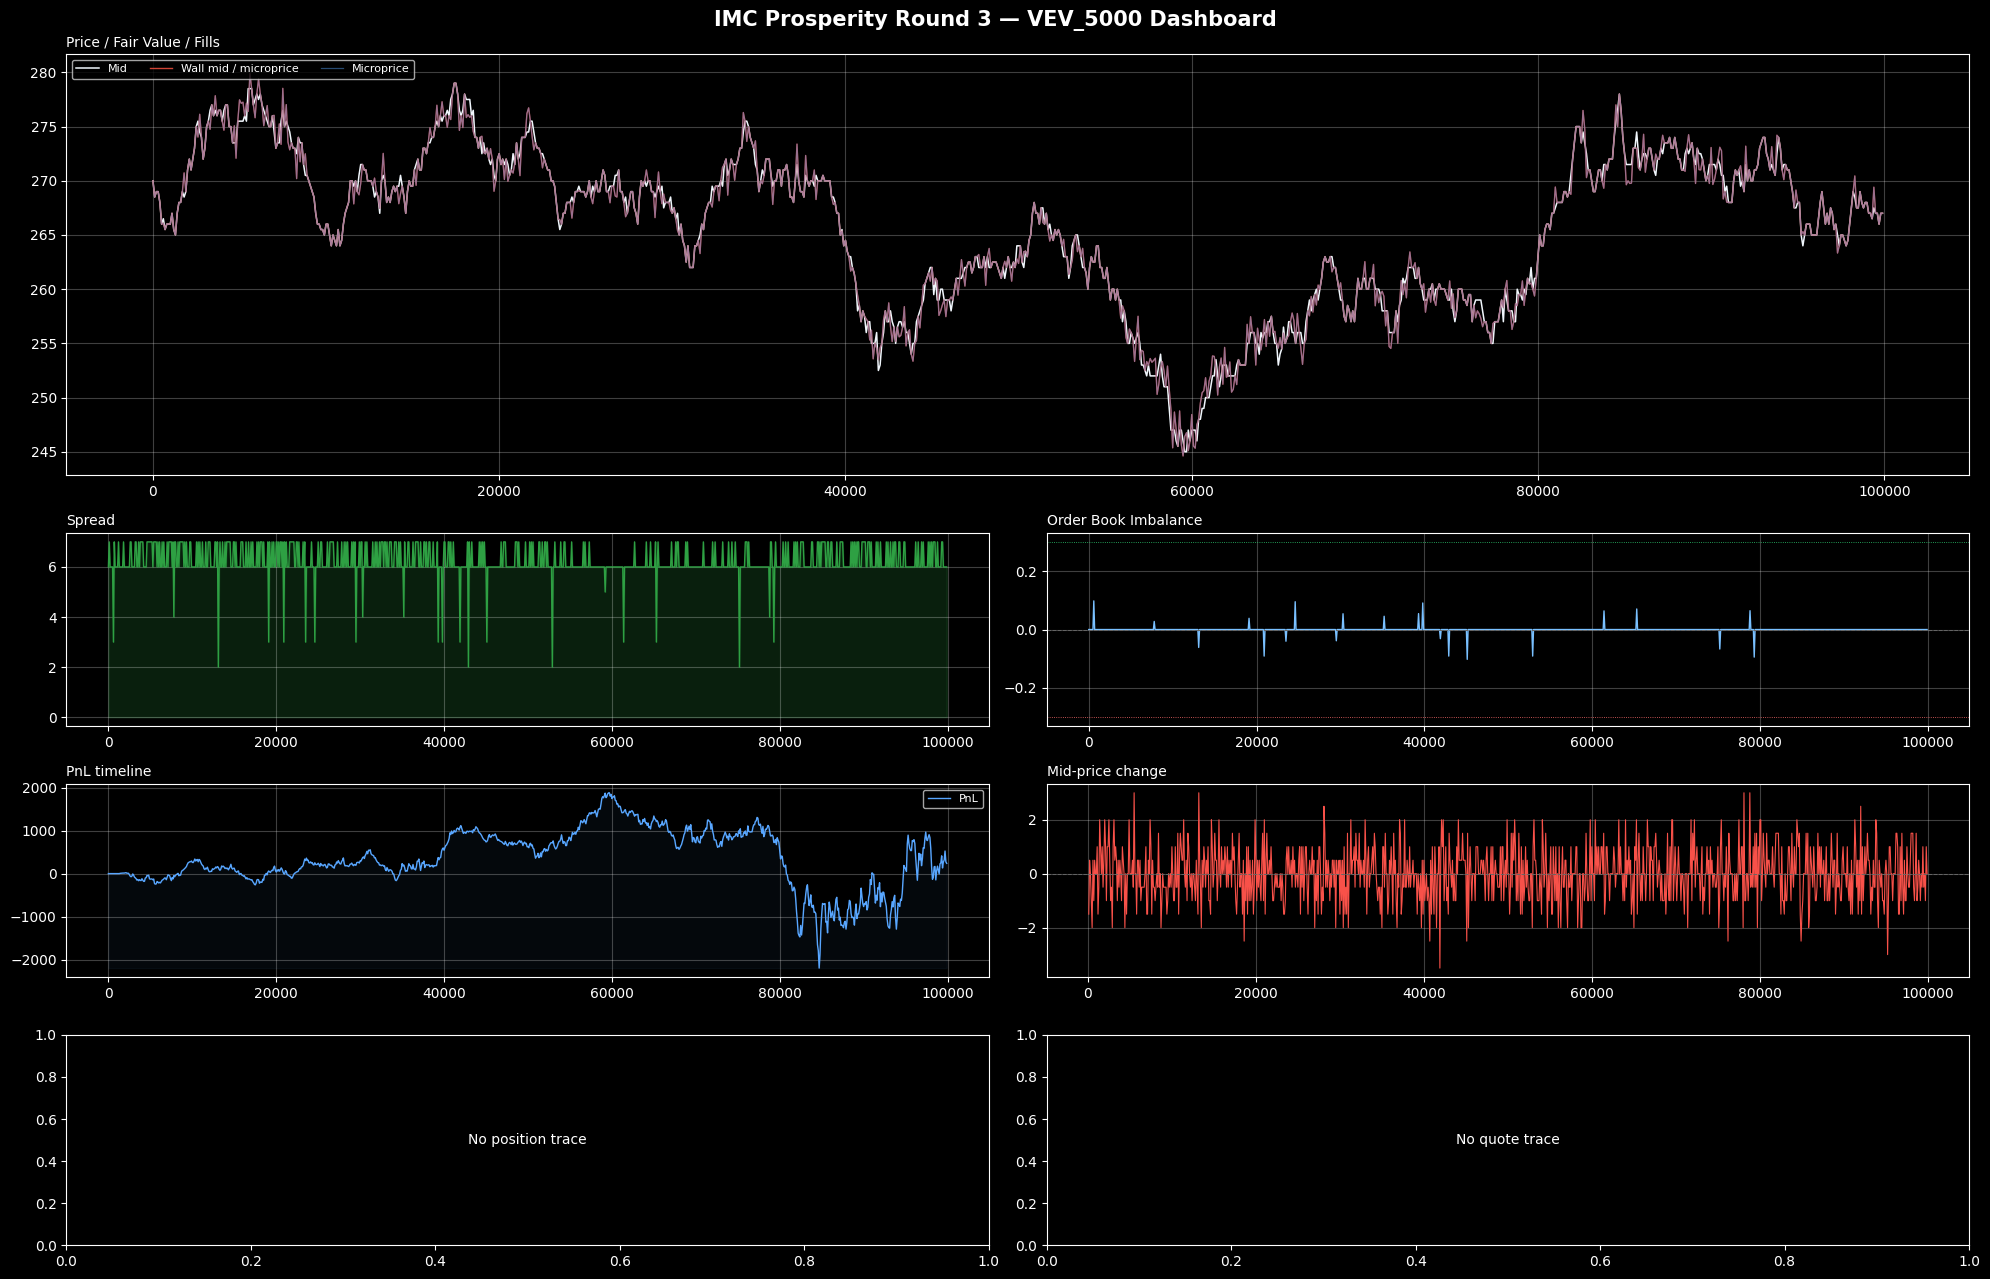

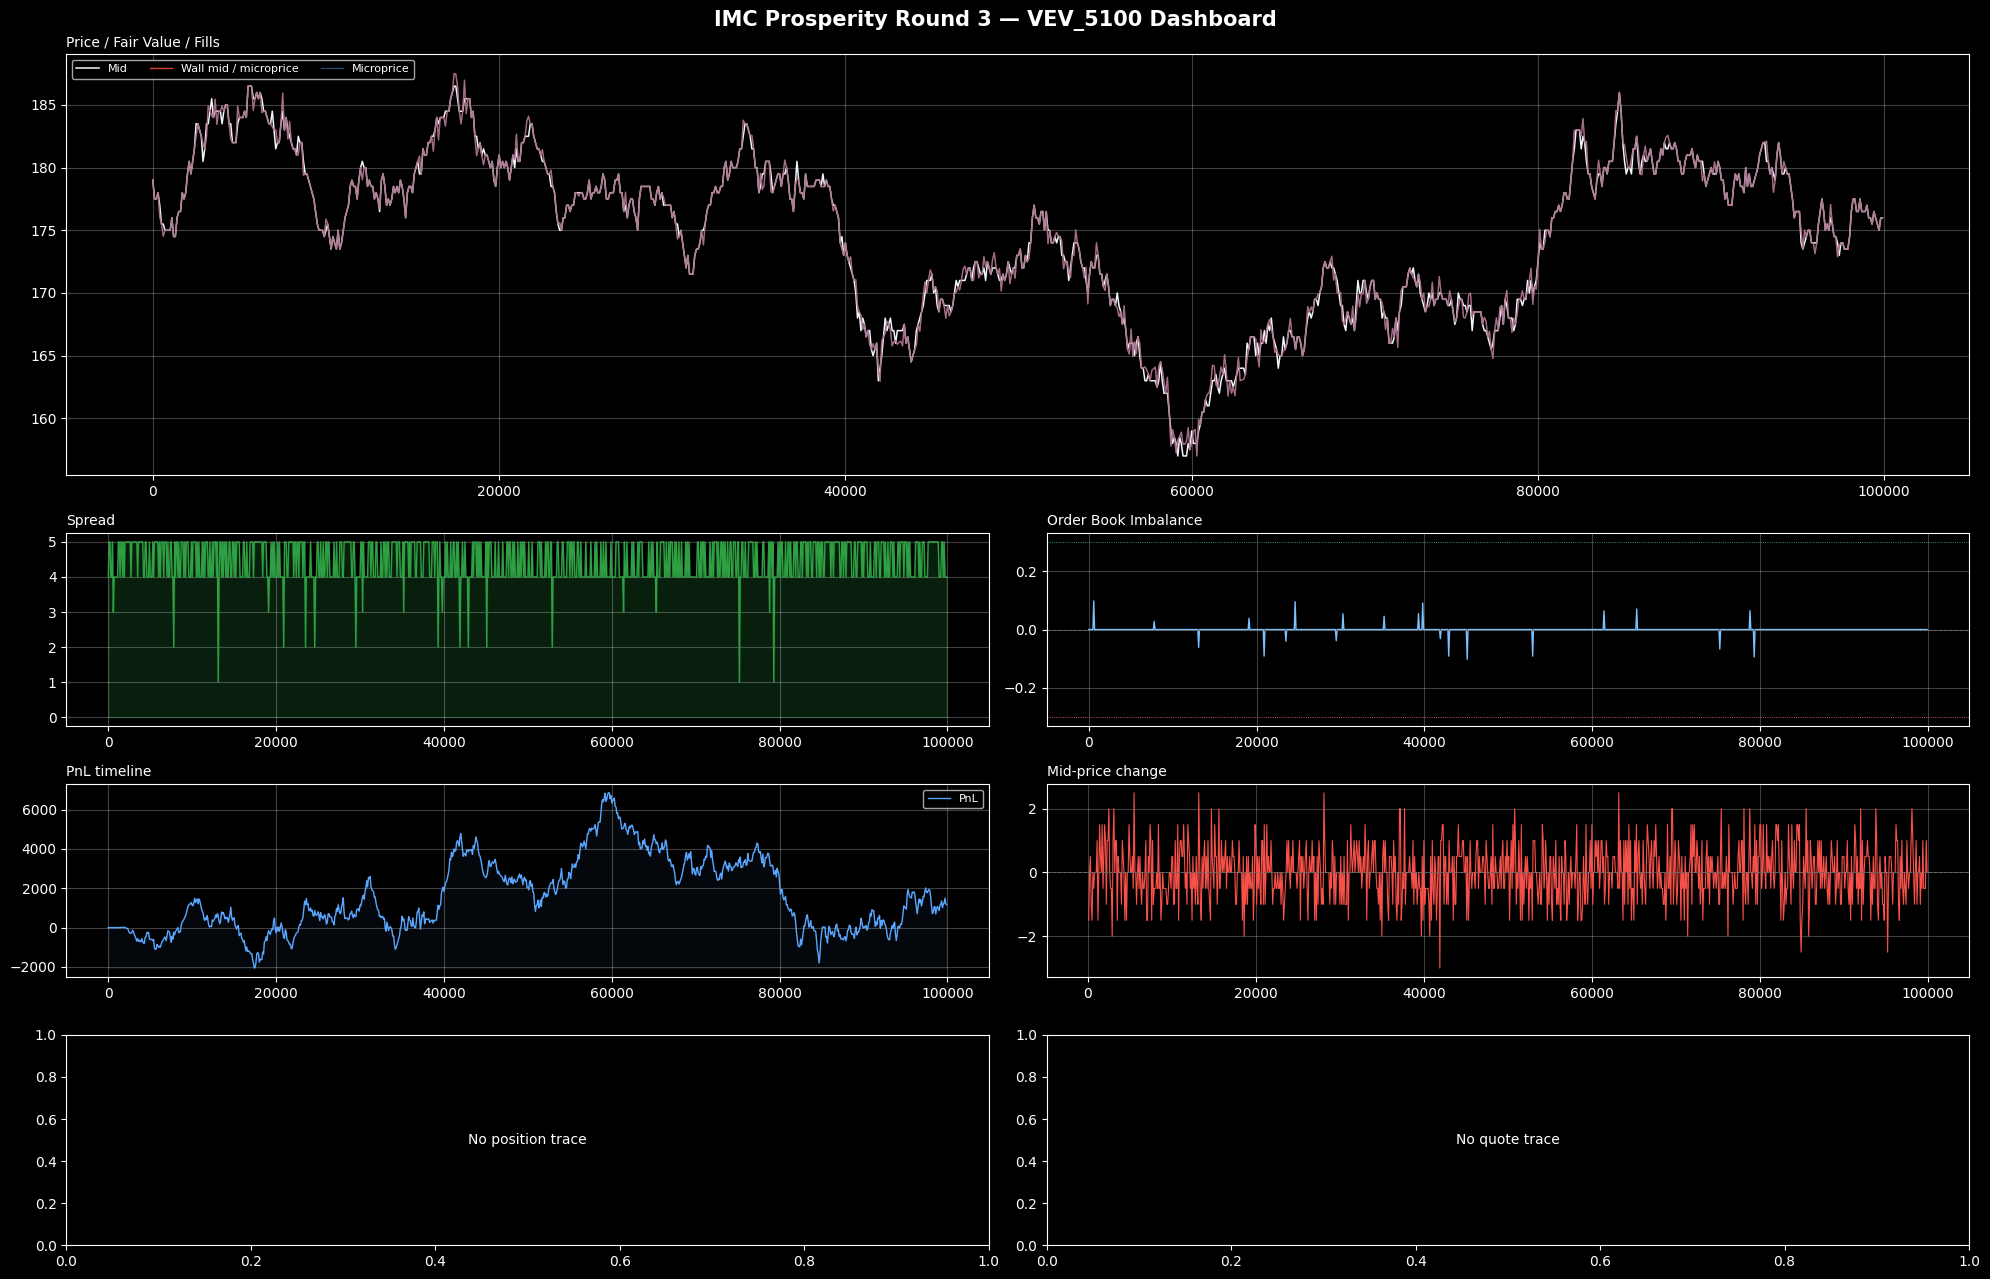

In [45]:
def drawdown_series(pnl: pd.Series) -> pd.Series:
    if pnl is None or pnl.empty:
        return pd.Series(dtype=float)
    pnl = pd.to_numeric(pnl, errors="coerce").fillna(method="ffill").fillna(0.0)
    return pnl.cummax() - pnl


def autocorr(series: pd.Series, lag: int = 1) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) <= lag + 2:
        return np.nan
    return s.autocorr(lag=lag)


def hurst_exponent(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna().values
    if len(s) < 20:
        return np.nan
    # Simple rescaled-range style estimator
    lags = np.arange(2, min(30, len(s) // 2))
    tau = []
    for lag in lags:
        diff = s[lag:] - s[:-lag]
        tau.append(np.sqrt(np.std(diff)))
    tau = np.array(tau)
    lags = lags[:len(tau)]
    if len(tau) < 3 or np.any(tau <= 0):
        return np.nan
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return 2.0 * poly[0]


def product_dashboard(product: str):
    df = mkt[product].copy()
    pts = trades[(trades.get("symbol", pd.Series(dtype=str)).astype(str) == product)] if not trades.empty else pd.DataFrame()

    fig = plt.figure(figsize=(20, 13))
    fig.suptitle(f"IMC Prosperity Round 3 — {product} Dashboard", fontsize=15, fontweight="bold", y=0.98)
    gs = gridspec.GridSpec(4, 2, figure=fig, height_ratios=[2.4, 1.1, 1.1, 1.2])

    # Price panel
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df["timestamp"], df["mid_price"], lw=1.1, color=C["mid"], label="Mid")
    ax1.plot(df["timestamp"], df["wall_mid"], lw=1.0, color=C["micro"], label="Wall mid / microprice", alpha=0.9)
    if "microprice" in df.columns:
        ax1.plot(df["timestamp"], df["microprice"], lw=0.9, color=C["spot"], alpha=0.45, label="Microprice")
    if f"{product}_fv" in df.columns:
        ax1.plot(df["timestamp"], df[f"{product}_fv"], lw=1.2, ls="--", color=C["ema"], label="Logger FV / EMA")
    if f"{product}_bid" in df.columns and f"{product}_ask" in df.columns:
        ax1.plot(df["timestamp"], df[f"{product}_bid"], lw=0.8, ls=":", color="#79c0ff", alpha=0.8, label="Our bid")
        ax1.plot(df["timestamp"], df[f"{product}_ask"], lw=0.8, ls=":", color="#ffa198", alpha=0.8, label="Our ask")
    if not pts.empty and "price" in pts.columns:
        buys = pts[pts["side"].eq("BUY")]
        sells = pts[pts["side"].eq("SELL")]
        if not buys.empty:
            ax1.scatter(buys["timestamp"], buys["price"], s=12, color=C["buy"], marker="^", alpha=0.9, label="Buy fills")
        if not sells.empty:
            ax1.scatter(sells["timestamp"], sells["price"], s=12, color=C["sell"], marker="v", alpha=0.9, label="Sell fills")
    ax1.set_title("Price / Fair Value / Fills", loc="left", fontsize=10)
    ax1.grid(True, alpha=0.25)
    ax1.legend(fontsize=8, ncol=4, loc="upper left")

    # Spread and imbalance
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(df["timestamp"], df["spread"], color=C["alpha"], lw=1.0)
    ax2.fill_between(df["timestamp"], df["spread"], alpha=0.2, color=C["alpha"])
    ax2.set_title("Spread", loc="left", fontsize=10)
    ax2.grid(True, alpha=0.25)

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(df["timestamp"], df["imbalance"], color=C["pressure"], lw=1.0)
    ax3.axhline(0, color="#666", lw=0.7, ls="--")
    ax3.axhline(0.3, color=C["buy"], lw=0.6, ls=":")
    ax3.axhline(-0.3, color=C["sell"], lw=0.6, ls=":")
    ax3.set_title("Order Book Imbalance", loc="left", fontsize=10)
    ax3.grid(True, alpha=0.25)

    # PnL / drawdown
    ax4 = fig.add_subplot(gs[2, 0])
    if "pnl" in df.columns and df["pnl"].notna().any():
        pnl = df["pnl"].fillna(method="ffill").fillna(0.0)
        dd = drawdown_series(pnl)
        ax4.plot(df["timestamp"], pnl, color=C["spot"], lw=1.0, label="PnL")
        ax4.fill_between(df["timestamp"], pnl.min(), pnl, alpha=0.05, color=C["spot"])
        ax4.set_title("PnL timeline", loc="left", fontsize=10)
        ax4.grid(True, alpha=0.25)
        ax4.legend(fontsize=8)
    else:
        ax4.text(0.5, 0.5, "No pnl column", ha="center", va="center", transform=ax4.transAxes)

    ax5 = fig.add_subplot(gs[2, 1])
    ax5.plot(df["timestamp"], df["mid_chg"], color=C["theta"], lw=0.8)
    ax5.axhline(0, color="#666", lw=0.7, ls="--")
    ax5.set_title("Mid-price change", loc="left", fontsize=10)
    ax5.grid(True, alpha=0.25)

    # Position / quote diagnostics
    ax6 = fig.add_subplot(gs[3, 0])
    pos_col = f"{product}_pos"
    if pos_col in df.columns:
        lim = 300 if product.startswith("VEV_") else 200
        ax6.plot(df["timestamp"], df[pos_col] / lim * 100, color=C["ema"], lw=1.0)
        ax6.axhline(0, color="#666", lw=0.7, ls="--")
        ax6.axhline(80, color=C["buy"], lw=0.6, ls=":")
        ax6.axhline(-80, color=C["sell"], lw=0.6, ls=":")
        ax6.set_title("Position as % of limit", loc="left", fontsize=10)
        ax6.grid(True, alpha=0.25)
    else:
        ax6.text(0.5, 0.5, "No position trace", ha="center", va="center", transform=ax6.transAxes)

    ax7 = fig.add_subplot(gs[3, 1])
    if f"{product}_bid" in df.columns and f"{product}_ask" in df.columns:
        ax7.plot(df["timestamp"], df[f"{product}_bid"], lw=0.8, color=C["buy"], label="Bid")
        ax7.plot(df["timestamp"], df[f"{product}_ask"], lw=0.8, color=C["sell"], label="Ask")
        ax7.set_title("Logger quote trace", loc="left", fontsize=10)
        ax7.legend(fontsize=8)
        ax7.grid(True, alpha=0.25)
    else:
        ax7.text(0.5, 0.5, "No quote trace", ha="center", va="center", transform=ax7.transAxes)

    plt.tight_layout()
    plt.show()

for p in spot_products + voucher_products[:4]:
    if p in mkt:
        product_dashboard(p)

## 4 — Quote stability & bot refresh cadence

In [46]:
for p in products:
    df = mkt[p]
    print(f"\n═══ {p} — Quote stability ═══")

    bid_changes = (df["bid_price_1"].diff() != 0).sum()
    ask_changes = (df["ask_price_1"].diff() != 0).sum()
    total = len(df)

    print(f"  Best bid changes : {bid_changes}/{total} ({100*bid_changes/total:.1f}%)")
    print(f"  Best ask changes : {ask_changes}/{total} ({100*ask_changes/total:.1f}%)")
    print(f"  Spread mean/std   : {df['spread'].mean():.2f} / {df['spread'].std():.2f}")

    top_bids = df["bid_price_1"].value_counts().head(5).to_dict()
    top_asks = df["ask_price_1"].value_counts().head(5).to_dict()
    print(f"  Top bid prices    : {top_bids}")
    print(f"  Top ask prices    : {top_asks}")

    if f"{p}_bid" in df.columns and f"{p}_ask" in df.columns:
        inside_bid = (df[f"{p}_bid"] > df["bid_price_1"]).mean()
        inside_ask = (df[f"{p}_ask"] < df["ask_price_1"]).mean()
        print(f"  Our bid inside bot spread : {100*inside_bid:.1f}%")
        print(f"  Our ask inside bot spread : {100*inside_ask:.1f}%")


═══ HYDROGEL_PACK — Quote stability ═══
  Best bid changes : 808/1000 (80.8%)
  Best ask changes : 805/1000 (80.5%)
  Spread mean/std   : 15.64 / 1.62
  Top bid prices    : {9985: 21, 10011: 20, 9939: 19, 9978: 18, 9944: 18}
  Top ask prices    : {10001: 20, 9994: 19, 9960: 19, 9954: 18, 9953: 18}

═══ VELVETFRUIT_EXTRACT — Quote stability ═══
  Best bid changes : 640/1000 (64.0%)
  Best ask changes : 638/1000 (63.8%)
  Spread mean/std   : 4.98 / 0.88
  Top bid prices    : {5264: 77, 5266: 76, 5263: 56, 5265: 54, 5268: 49}
  Top ask prices    : {5269: 76, 5271: 70, 5270: 58, 5268: 57, 5267: 54}

═══ VEV_4000 — Quote stability ═══
  Best bid changes : 610/1000 (61.0%)
  Best ask changes : 611/1000 (61.1%)
  Spread mean/std   : 20.97 / 1.57
  Top bid prices    : {1256: 81, 1258: 73, 1255: 58, 1257: 54, 1260: 51}
  Top ask prices    : {1277: 75, 1279: 70, 1278: 59, 1276: 54, 1280: 53}

═══ VEV_4500 — Quote stability ═══
  Best bid changes : 611/1000 (61.1%)
  Best ask changes : 617/1000 

## 5 — Price statistics, stationarity, and EMA tracking quality

In [47]:
def price_stats(series: pd.Series) -> dict:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return {}
    ret = s.diff().dropna()
    return {
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "max": s.max(),
        "autocorr_1": autocorr(s, 1),
        "autocorr_5": autocorr(s, 5),
        "hurst": hurst_exponent(s),
        "ret_std": ret.std() if len(ret) else np.nan,
        "ret_skew_proxy": ret.mean() / (ret.std() + 1e-9) if len(ret) else np.nan,
    }

for p in products:
    df = mkt[p]
    st = price_stats(df["mid_price"])
    print(f"\n═══ {p} — Price statistics ═══")
    for k, v in st.items():
        print(f"  {k:>14}: {v: .5f}")

    # EMA sweep for underlying products
    if p in SPOT_PRODUCTS:
        alphas = np.linspace(0.01, 0.30, 15)
        corrs = []
        mse = []
        for a in alphas:
            ema = df["mid_price"].ewm(alpha=a, adjust=False).mean()
            pred = ema.shift(1)
            next_ret = df["mid_price"].diff().shift(-1)
            valid = ~(pred.isna() | next_ret.isna())
            if valid.sum() < 10:
                corrs.append(np.nan); mse.append(np.nan); continue
            corrs.append(pd.Series(pred[valid]).corr(pd.Series(next_ret[valid]), method="spearman"))
            mse.append(((df["mid_price"] - ema).pow(2)).mean())
        best_idx = int(np.nanargmax(np.abs(corrs))) if np.any(~np.isnan(corrs)) else None
        if best_idx is not None:
            print(f"  Best EMA alpha (signal): {alphas[best_idx]:.3f}, IC={corrs[best_idx]:+.4f}")


═══ HYDROGEL_PACK — Price statistics ═══
            mean:  9979.29350
             std:  29.69704
             min:  9915.00000
             max:  10031.00000
      autocorr_1:  0.99706
      autocorr_5:  0.98828
           hurst:  0.49802
         ret_std:  2.27591
  ret_skew_proxy: -0.02243
  Best EMA alpha (signal): 0.031, IC=-0.0515

═══ VELVETFRUIT_EXTRACT — Price statistics ═══
            mean:  5262.37850
             std:  7.51988
             min:  5241.50000
             max:  5276.50000
      autocorr_1:  0.98809
      autocorr_5:  0.95675
           hurst:  0.49649
         ret_std:  1.16122
  ret_skew_proxy: -0.00302
  Best EMA alpha (signal): 0.072, IC=-0.0555

═══ VEV_4000 — Price statistics ═══
            mean:  1262.39050
             std:  7.55522
             min:  1241.50000
             max:  1276.50000
      autocorr_1:  0.98233
      autocorr_5:  0.94924
           hurst:  0.45660
         ret_std:  1.42066
  ret_skew_proxy: -0.00247

═══ VEV_4500 — Price sta

## 6 — PnL timeline, attribution, drawdown, and recovery

═══ PnL metrics ═══

HYDROGEL_PACK:
       final_pnl: 11,520.0000
    max_drawdown: 11,657.6250
  recovery_ratio: 0.9882

VELVETFRUIT_EXTRACT:
       final_pnl: 2,269.9062
    max_drawdown: 2,688.5000
  recovery_ratio: 0.8443

VEV_4000:
       final_pnl: -2.6904
    max_drawdown: 149.6953
  recovery_ratio: -0.0180

VEV_4500:
       final_pnl: -2.6904
    max_drawdown: 149.6953
  recovery_ratio: -0.0180

VEV_5000:
       final_pnl: 238.6094
    max_drawdown: 4,075.1768
  recovery_ratio: 0.0586

VEV_5100:
       final_pnl: 1,172.2930
    max_drawdown: 8,644.4336
  recovery_ratio: 0.1356

VEV_5200:
       final_pnl: -41.2617
    max_drawdown: 6,648.7832
  recovery_ratio: -0.0062

VEV_5300:
       final_pnl: 183.5830
    max_drawdown: 4,106.5273
  recovery_ratio: 0.0447

VEV_5400:
       final_pnl: 50.8761
    max_drawdown: 154.5475
  recovery_ratio: 0.3292

VEV_5500:
       final_pnl: -18.7917
    max_drawdown: 818.2838
  recovery_ratio: -0.0230

VEV_6000:
       final_pnl: 0.0000
    max

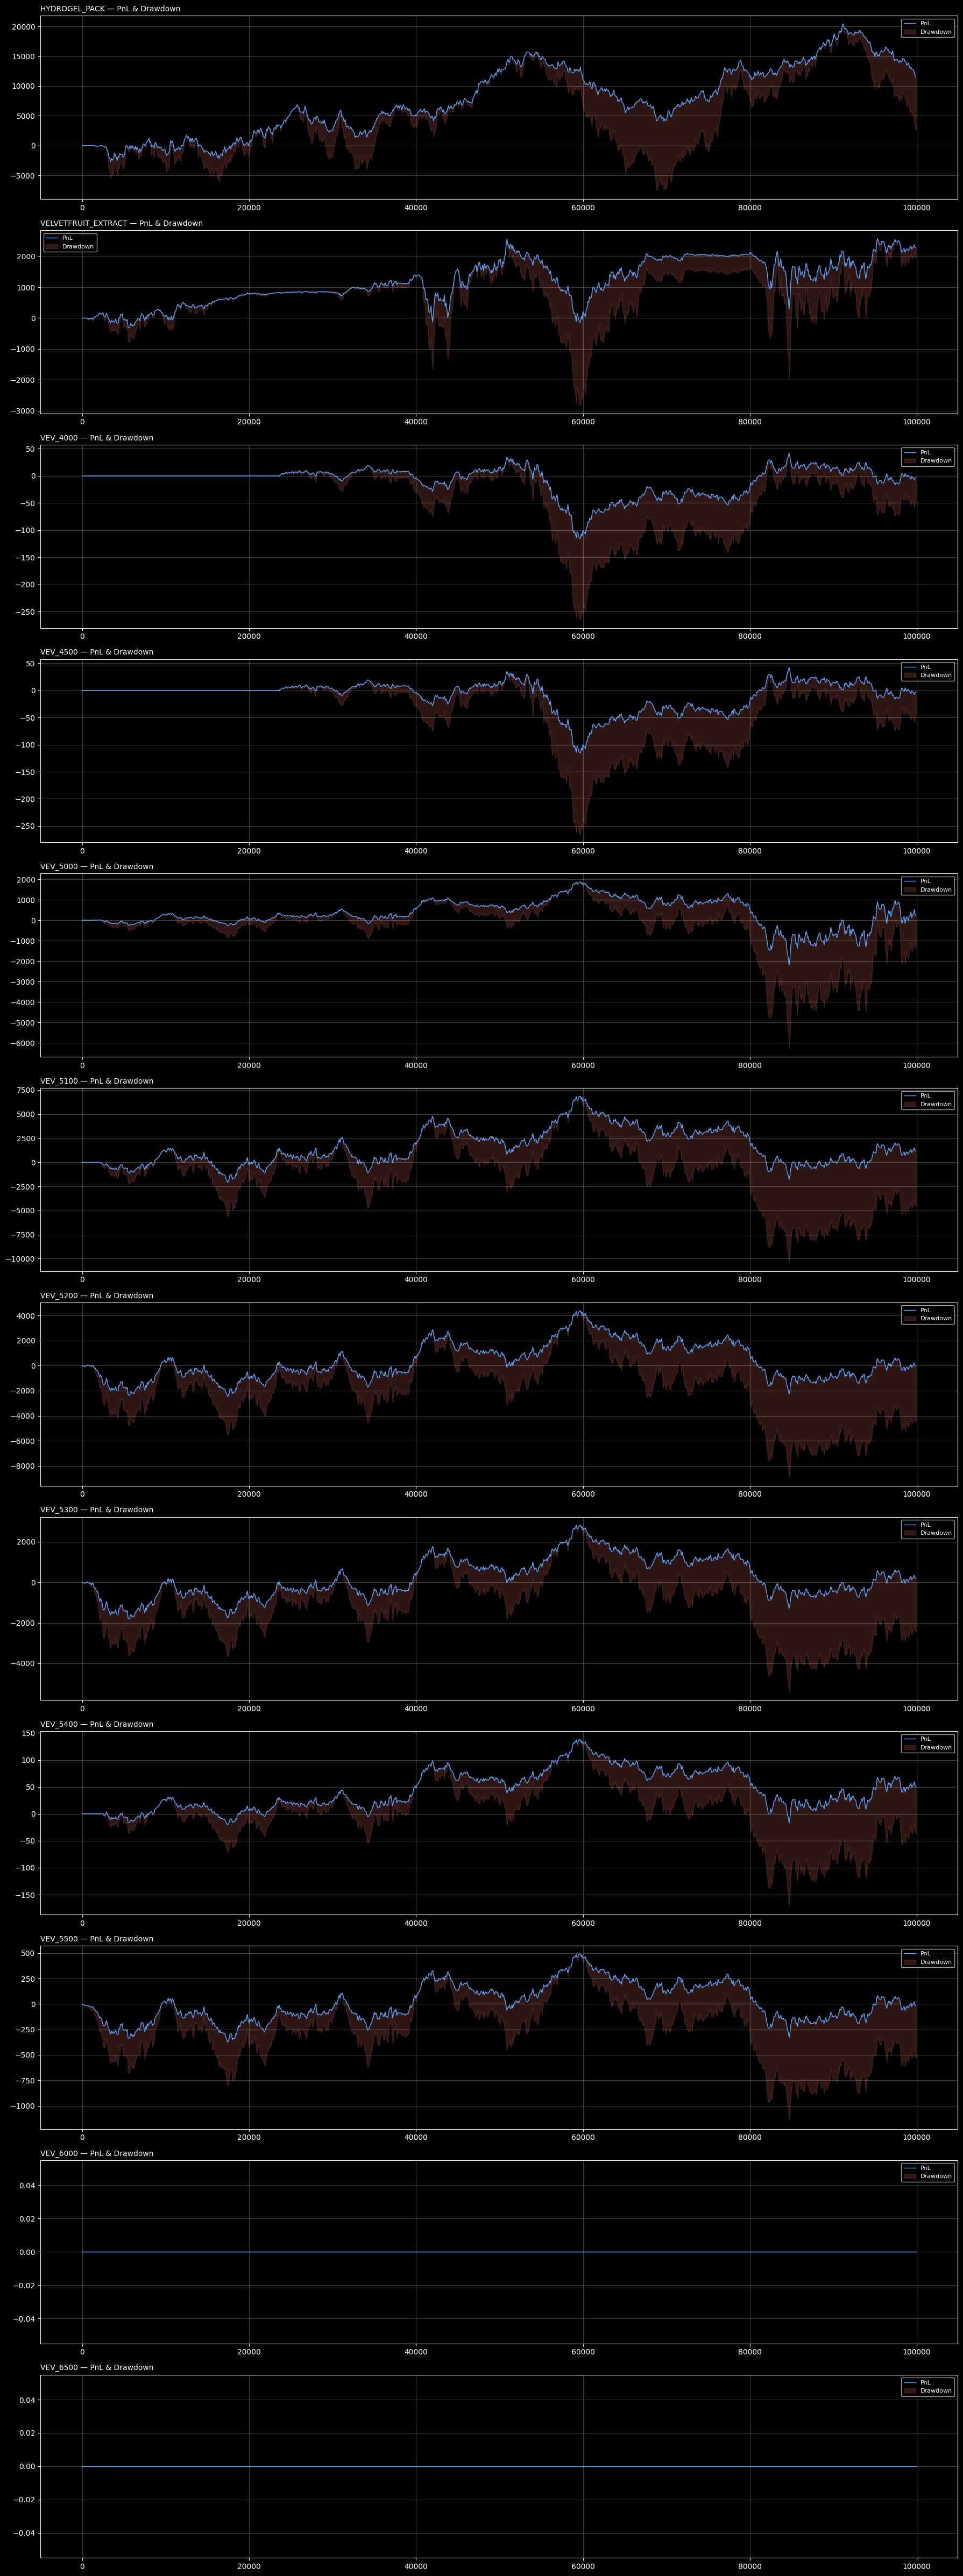

In [48]:
def product_pnl_metrics(df: pd.DataFrame) -> dict:
    if "pnl" not in df.columns or df["pnl"].dropna().empty:
        return {}
    pnl = pd.to_numeric(df["pnl"], errors="coerce").fillna(method="ffill").fillna(0.0)
    dd = drawdown_series(pnl)
    max_dd = dd.max() if len(dd) else np.nan
    final = pnl.iloc[-1]
    recovery = final / (max_dd + 1e-9) if max_dd and max_dd > 0 else np.nan
    return {"final_pnl": final, "max_drawdown": max_dd, "recovery_ratio": recovery}

print("═══ PnL metrics ═══")
for p in products:
    df = mkt[p]
    m = product_pnl_metrics(df)
    if not m:
        continue
    print(f"\n{p}:")
    for k, v in m.items():
        print(f"  {k:>14}: {v:,.4f}")

fig, axes = plt.subplots(len(products), 1, figsize=(18, 4*len(products)), sharex=False)
if len(products) == 1:
    axes = [axes]
for ax, p in zip(axes, products):
    df = mkt[p]
    if "pnl" not in df.columns or df["pnl"].dropna().empty:
        ax.text(0.5, 0.5, "No PnL data", ha="center", va="center", transform=ax.transAxes)
        continue
    pnl = pd.to_numeric(df["pnl"], errors="coerce").fillna(method="ffill").fillna(0.0)
    dd = drawdown_series(pnl)
    ax.plot(df["timestamp"], pnl, lw=1.0, color=C["spot"], label="PnL")
    ax.fill_between(df["timestamp"], pnl - dd, pnl, alpha=0.18, color=C["drawdown"], label="Drawdown")
    ax.set_title(f"{p} — PnL & Drawdown", loc="left", fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7 — Fill rate, fill price, and adverse selection

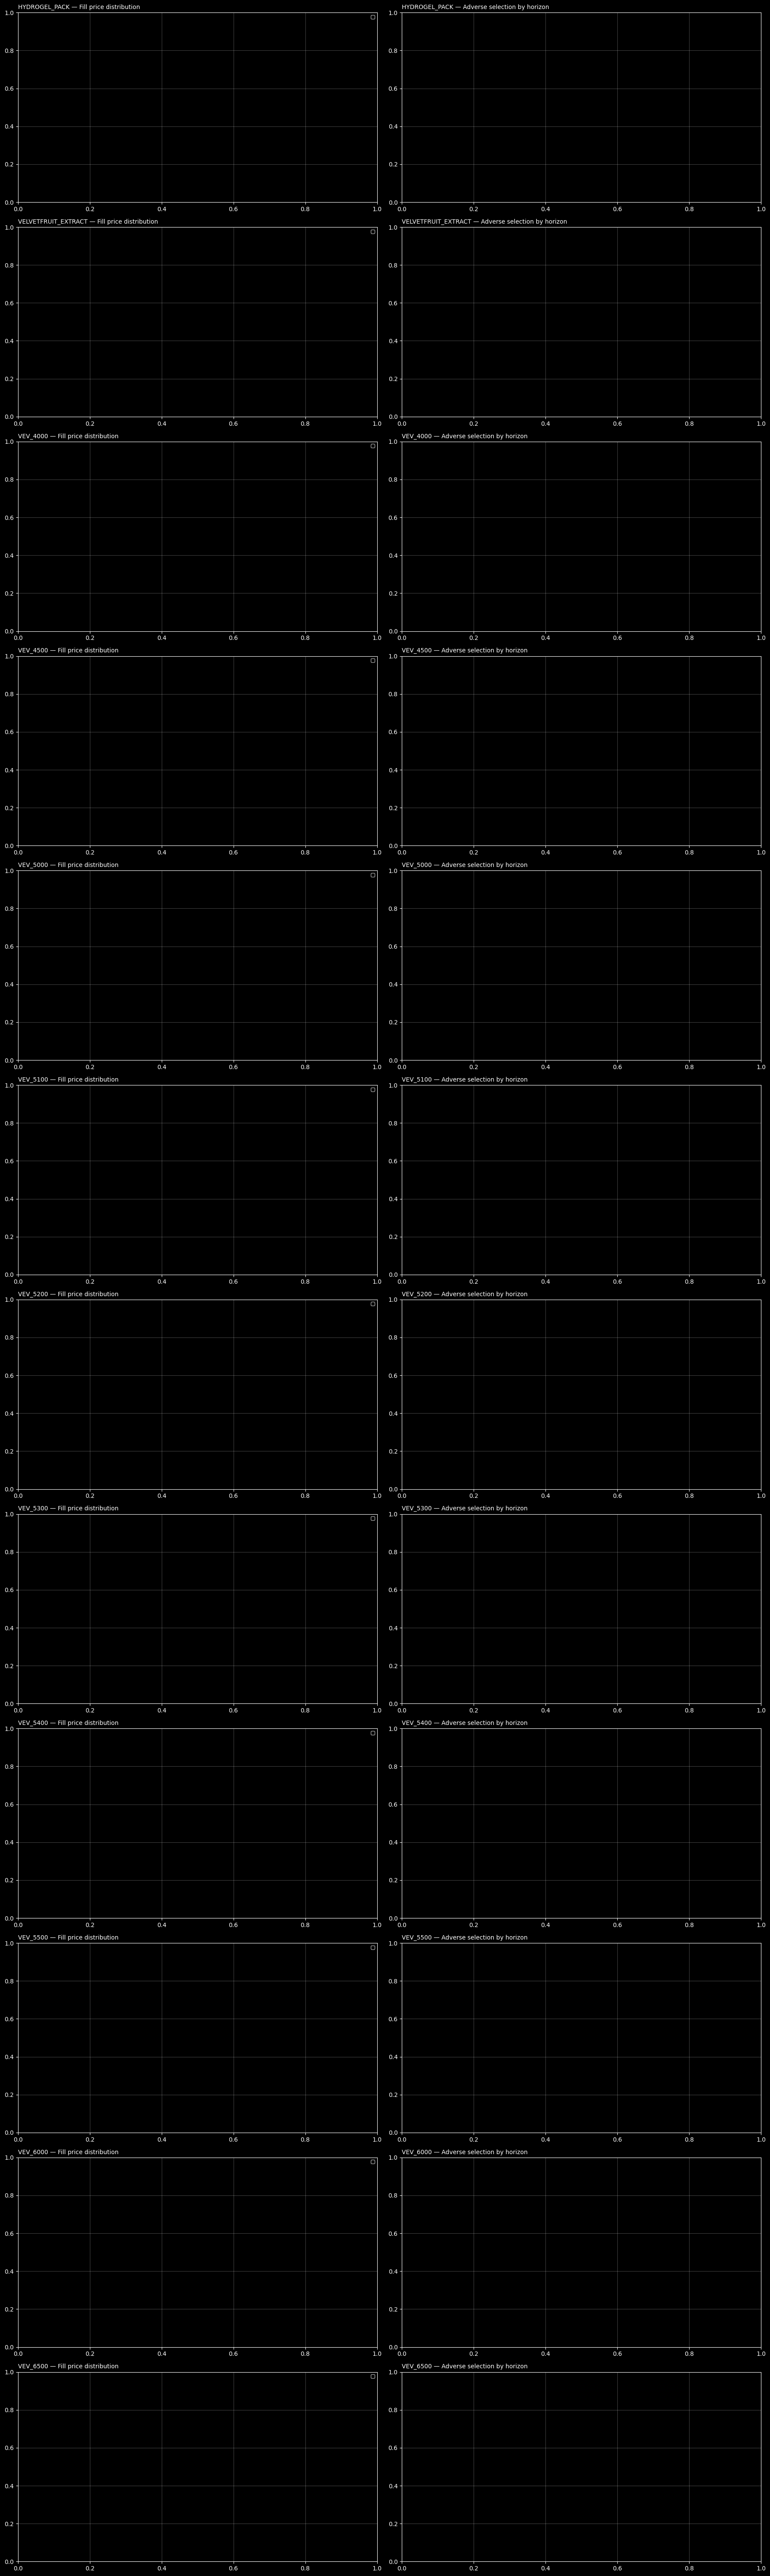

In [49]:
def fill_toxicity_by_horizon(df: pd.DataFrame, trade_df: pd.DataFrame, product: str, horizons=(1, 5, 10, 20)) -> pd.DataFrame:
    """
    For each of our fills, measure post-fill mid-price move at several horizons.
    Positive values are good for the direction of the fill.
    """
    if trade_df.empty or "symbol" not in trade_df.columns or "timestamp" not in trade_df.columns:
        return pd.DataFrame()

    pts = trade_df[(trade_df["symbol"].astype(str) == product) & (trade_df.get("is_our_trade", False))].copy()
    if pts.empty:
        return pd.DataFrame()

    m = df[["timestamp", "mid_price"]].dropna().sort_values("timestamp")
    if m.empty:
        return pd.DataFrame()

    out = []
    ts_arr = m["timestamp"].to_numpy()
    mid_arr = m["mid_price"].to_numpy()

    for _, tr in pts.iterrows():
        ts = tr["timestamp"]
        idx = np.searchsorted(ts_arr, ts, side="left")
        if idx >= len(ts_arr):
            continue

        side = tr.get("side", "OTHER")
        fill_price = tr.get("price", np.nan)
        fill_qty = abs(tr.get("quantity", np.nan))
        if np.isnan(fill_price) or np.isnan(fill_qty):
            continue

        for h in horizons:
            j = min(idx + h, len(ts_arr) - 1)
            future_mid = mid_arr[j]
            if side == "BUY":
                pnl_imp = future_mid - fill_price
            elif side == "SELL":
                pnl_imp = fill_price - future_mid
            else:
                pnl_imp = np.nan
            out.append({
                "product": product,
                "timestamp": ts,
                "side": side,
                "horizon": h,
                "fill_price": fill_price,
                "future_mid": future_mid,
                "impact": pnl_imp,
                "qty": fill_qty,
            })

    return pd.DataFrame(out)


toxicity_rows = []
for p in products:
    df = mkt[p]
    pts = trades[(trades.get("symbol", pd.Series(dtype=str)).astype(str) == p) & trades.get("is_our_trade", False)] if not trades.empty else pd.DataFrame()
    if pts.empty:
        continue
    tox = fill_toxicity_by_horizon(df, trades, p, horizons=(1, 5, 10, 20))
    if tox.empty:
        continue
    toxicity_rows.append(tox)

toxicity = pd.concat(toxicity_rows, ignore_index=True) if toxicity_rows else pd.DataFrame()

for p in products:
    pts = our_trades[our_trades.get("symbol", pd.Series(dtype=str)).astype(str) == p] if not our_trades.empty else pd.DataFrame()
    if pts.empty:
        continue
    buys = pts[pts["side"] == "BUY"]
    sells = pts[pts["side"] == "SELL"]
    print(f"\n═══ {p} — Fill analysis ═══")
    if not buys.empty:
        print(f"  Buy fills   : {len(buys):4d}  avg px={buys['price'].mean():.4f}  avg qty={buys['abs_qty'].mean():.2f}")
    if not sells.empty:
        print(f"  Sell fills  : {len(sells):4d}  avg px={sells['price'].mean():.4f}  avg qty={sells['abs_qty'].mean():.2f}")

    if not toxicity.empty:
        tx = toxicity[(toxicity["product"] == p)]
        if not tx.empty:
            for h in sorted(tx["horizon"].unique()):
                sub = tx[tx["horizon"] == h]
                print(f"  Horizon {h:>2}: impact mean={sub['impact'].mean():+.4f}  median={sub['impact'].median():+.4f}")

fig, axes = plt.subplots(len(products), 2, figsize=(18, 5*len(products)))
if len(products) == 1:
    axes = [axes]
for i, p in enumerate(products):
    ax1, ax2 = axes[i]
    pts = trades[(trades.get("symbol", pd.Series(dtype=str)).astype(str) == p)] if not trades.empty else pd.DataFrame()

    if not pts.empty and "price" in pts.columns:
        buys = pts[pts["side"] == "BUY"]
        sells = pts[pts["side"] == "SELL"]
        if not buys.empty:
            ax1.hist(buys["price"], bins=25, alpha=0.55, color=C["buy"], density=True, label="BUY")
        if not sells.empty:
            ax1.hist(sells["price"], bins=25, alpha=0.55, color=C["sell"], density=True, label="SELL")
    ax1.set_title(f"{p} — Fill price distribution", loc="left", fontsize=10)
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.25)

    if not toxicity.empty:
        sub = toxicity[toxicity["product"] == p]
        if not sub.empty:
            for h in sorted(sub["horizon"].unique()):
                hh = sub[sub["horizon"] == h]
                m = hh.groupby("side")["impact"].mean()
                ax2.bar([f"{h}-BUY", f"{h}-SELL"], [m.get("BUY", np.nan), m.get("SELL", np.nan)],
                        color=[C["buy"], C["sell"]], alpha=0.55)
    ax2.axhline(0, color="#666", lw=0.7)
    ax2.set_title(f"{p} — Adverse selection by horizon", loc="left", fontsize=10)
    ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 8 — Timestamp-synced inspection panel

In [50]:
INSPECT_TS = 0  # change this to inspect any timestamp
INSPECT_PRODUCT = spot_products[0] if spot_products else (products[0] if products else None)

if INSPECT_PRODUCT is not None:
    df = mkt[INSPECT_PRODUCT]
    row = df[df["timestamp"] == INSPECT_TS]
    print(f"Inspecting product={INSPECT_PRODUCT}, timestamp={INSPECT_TS}")
    if row.empty:
        print("No row found at that timestamp.")
    else:
        display(row.T.head(40))

    if not our_trades.empty:
        pts = our_trades[(our_trades["symbol"].astype(str) == INSPECT_PRODUCT) & (our_trades["timestamp"] == INSPECT_TS)]
        display(pts if not pts.empty else pd.DataFrame({"info": ["No our trades at this timestamp"]}))

Inspecting product=HYDROGEL_PACK, timestamp=0


,0
day,2
timestamp,0
product,HYDROGEL_PACK
bid_price_1,10003
bid_volume_1,13
bid_price_2,10001.0
bid_volume_2,21.0
bid_price_3,NaN
bid_volume_3,NaN
ask_price_1,10019


## 9 — TraderData state evolution viewer

In [51]:
def extract_state_trace(df: pd.DataFrame) -> pd.DataFrame:
    """
    If the log includes traderData or lambdaLog state traces, show them in a clean table.
    """
    if df.empty:
        return pd.DataFrame()
    for col in ["traderData", "traderdata", "lambdaLog", "lambdalog"]:
        if col in df.columns:
            out = df[["timestamp", col]].copy()
            out = out[out[col].notna()]
            return out
    return pd.DataFrame()

state_trace = extract_state_trace(activities)
print("TraderData / log state trace:")
display(state_trace.head(10) if not state_trace.empty else pd.DataFrame({"info": ["No traderData / lambdaLog column found"]}))

TraderData / log state trace:


,info
0,No traderData / lambdaLog column found


## 10 — Market trades analysis (non-SUBMISSION / other participants)

In [52]:
if trades.empty:
    print("No trade history parsed.")
else:
    other = trades[~trades.get("is_our_trade", False)].copy()
    print(f"Non-SUBMISSION trades: {len(other):,}")
    if not other.empty:
        summary = other.groupby("symbol").agg(
            trades=("symbol", "size"),
            avg_price=("price", "mean"),
            avg_qty=("abs_qty", "mean"),
            buy_ratio=("side", lambda s: (s == "BUY").mean() if len(s) else np.nan),
        ).sort_values("trades", ascending=False)
        display(summary)

No trade history parsed.


## 11 — Market dynamics: volatility, momentum, and spread efficiency

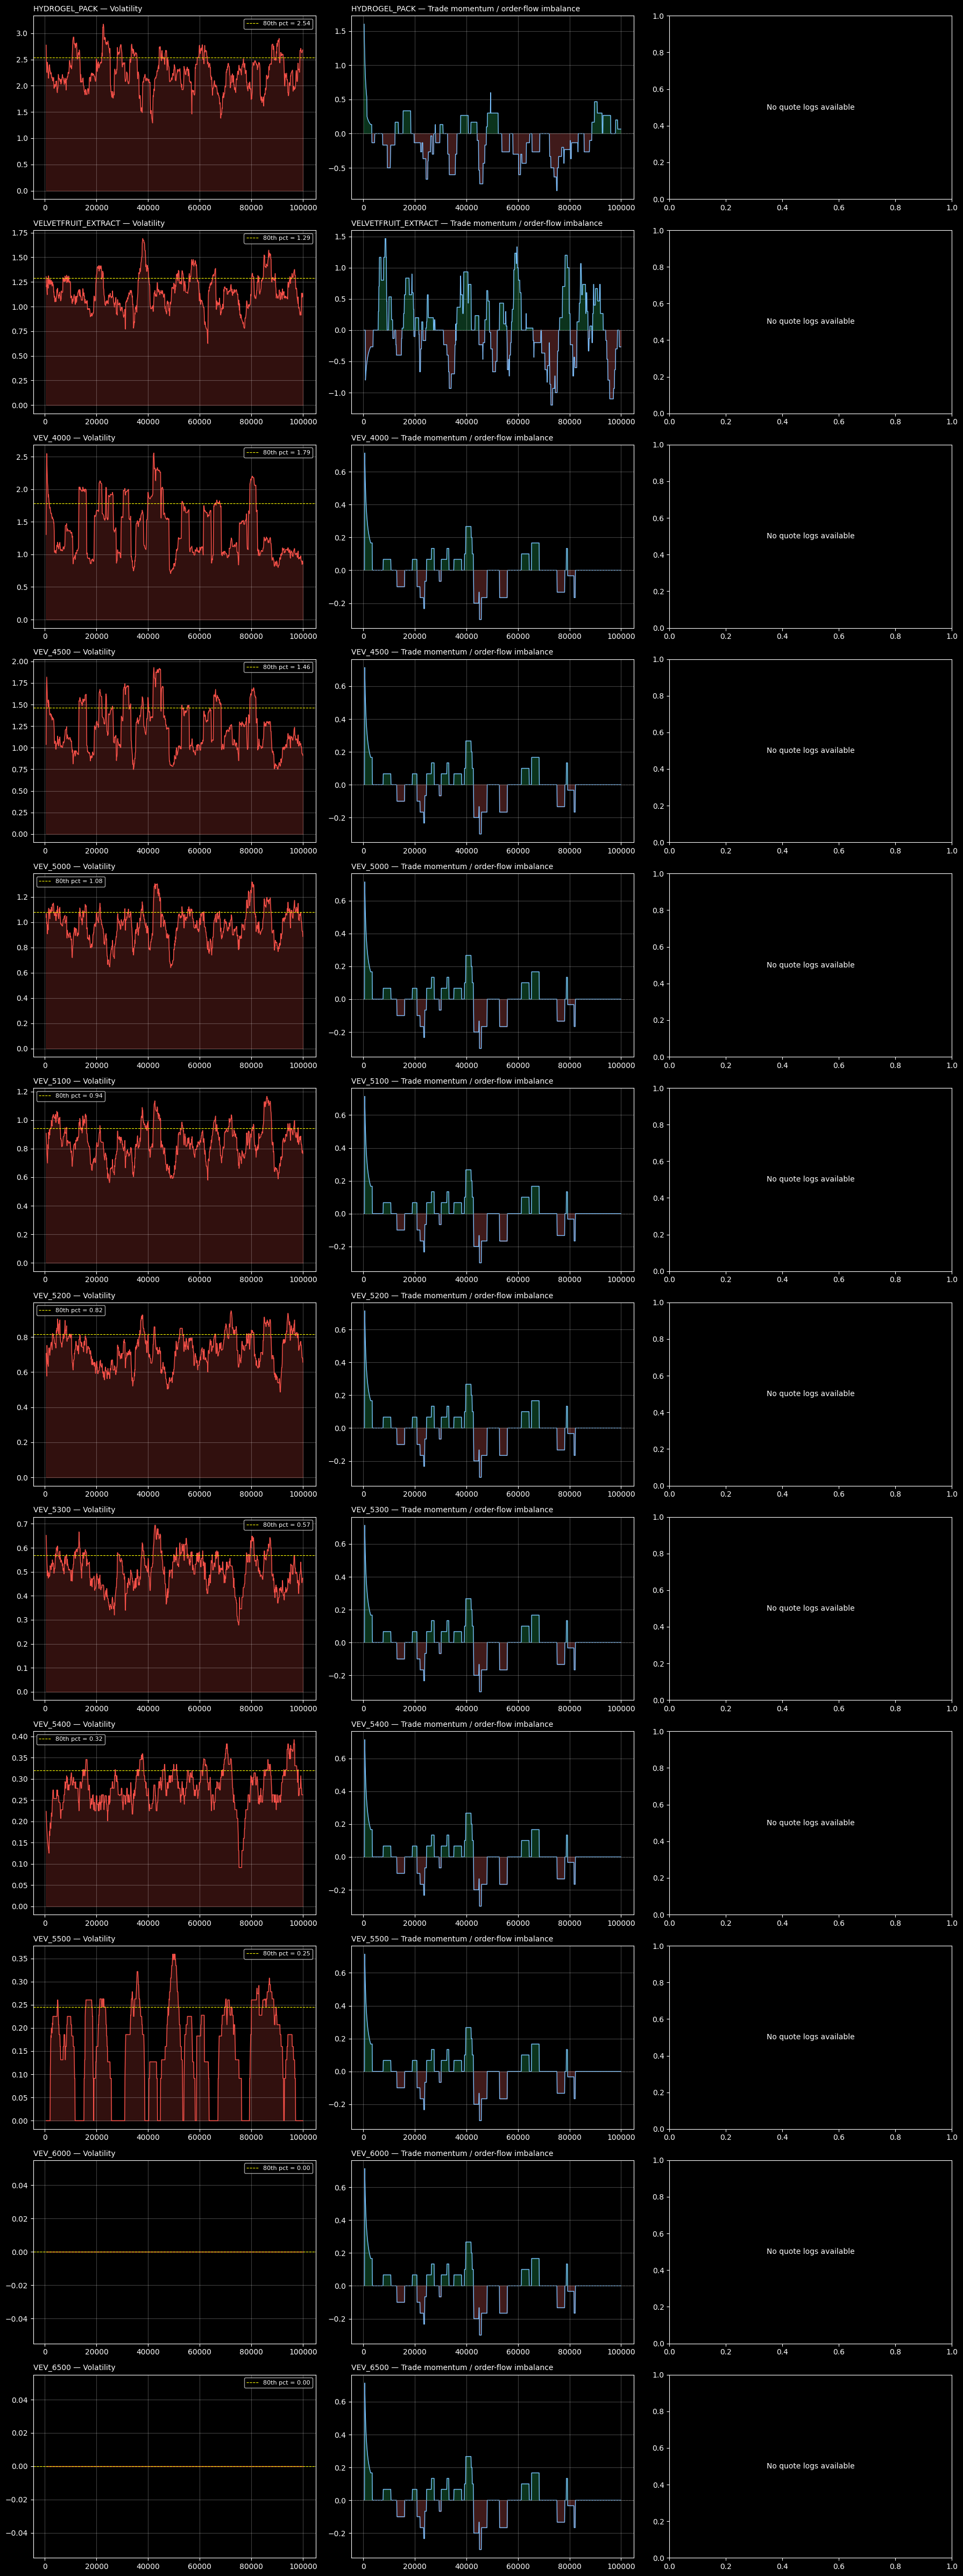

In [53]:
DYNAMICS_WINDOW = 30

fig, axes = plt.subplots(len(products), 3, figsize=(18, 4*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df = mkt[p].copy()
    ax_v, ax_m, ax_e = axes[i]

    df["vol_pts"] = df["mid_chg"].rolling(DYNAMICS_WINDOW, min_periods=5).std()
    ax_v.plot(df["timestamp"], df["vol_pts"], color=C["theta"], lw=1.0)
    ax_v.fill_between(df["timestamp"], df["vol_pts"], alpha=0.2, color=C["theta"])
    hv = df["vol_pts"].quantile(0.80)
    ax_v.axhline(hv, color="yellow", lw=0.8, ls="--", label=f"80th pct = {hv:.2f}")
    ax_v.set_title(f"{p} — Volatility", loc="left", fontsize=10)
    ax_v.legend(fontsize=8)
    ax_v.grid(True, alpha=0.25)

    df["signed_vol"] = df["bid_depth"] - df["ask_depth"]
    df["momentum"] = df["signed_vol"].rolling(DYNAMICS_WINDOW, min_periods=5).mean()
    ax_m.plot(df["timestamp"], df["momentum"], color=C["pressure"], lw=1.0)
    ax_m.fill_between(df["timestamp"], df["momentum"], where=df["momentum"] > 0, alpha=0.25, color=C["buy"])
    ax_m.fill_between(df["timestamp"], df["momentum"], where=df["momentum"] < 0, alpha=0.25, color=C["sell"])
    ax_m.axhline(0, color="#666", lw=0.7, ls="--")
    ax_m.set_title(f"{p} — Trade momentum / order-flow imbalance", loc="left", fontsize=10)
    ax_m.grid(True, alpha=0.25)

    if f"{p}_bid" in df.columns and f"{p}_ask" in df.columns:
        our_half = ((df[f"{p}_ask"] - df[f"{p}_bid"]) / 2).fillna(np.nan)
        bot_half = (df["spread"] / 2).replace(0, np.nan)
        eff = (our_half / bot_half * 100).clip(0, 100)
        df["spread_eff"] = eff
        ax_e.plot(df["timestamp"], eff, color=C["ema"], lw=1.0)
        ax_e.fill_between(df["timestamp"], eff, alpha=0.2, color=C["ema"])
        ax_e.axhline(80, color=C["buy"], lw=0.8, ls="--", label="Target 80%")
        ax_e.set_title(f"{p} — Spread efficiency", loc="left", fontsize=10)
        ax_e.legend(fontsize=8)
        ax_e.grid(True, alpha=0.25)
    else:
        ax_e.text(0.5, 0.5, "No quote logs available", ha="center", va="center", transform=ax_e.transAxes)

plt.tight_layout()
plt.show()

## 12 — Market pressure gauge

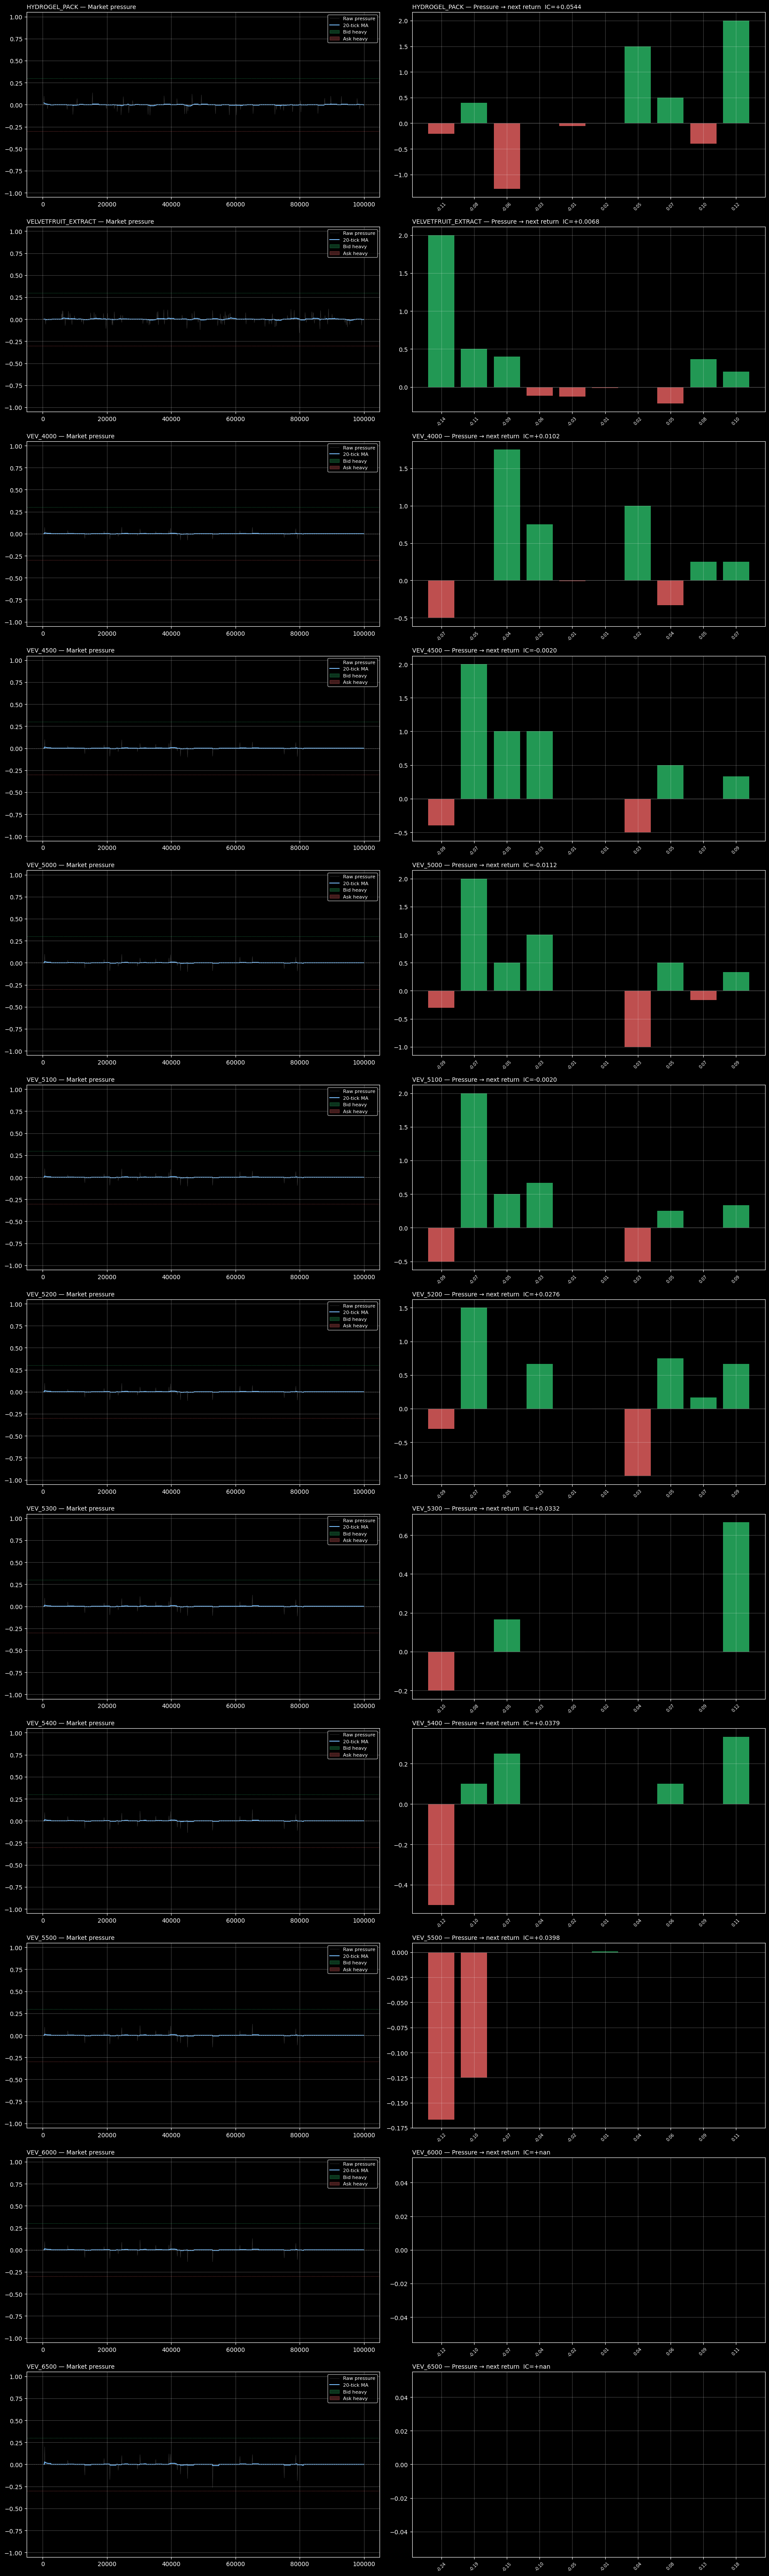

In [54]:
fig, axes = plt.subplots(len(products), 2, figsize=(18, 5*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df = mkt[p].copy()
    ax_l, ax_r = axes[i]

    pressure = df["imbalance"]
    roll_p = pressure.rolling(20, min_periods=5).mean()

    ax_l.plot(df["timestamp"], pressure, color="#999", lw=0.5, alpha=0.4, label="Raw pressure")
    ax_l.plot(df["timestamp"], roll_p, color=C["pressure"], lw=1.4, label="20-tick MA")
    ax_l.fill_between(df["timestamp"], roll_p, where=roll_p > 0.1, alpha=0.25, color=C["buy"], label="Bid heavy")
    ax_l.fill_between(df["timestamp"], roll_p, where=roll_p < -0.1, alpha=0.25, color=C["sell"], label="Ask heavy")
    ax_l.axhline(0, color="#666", lw=0.7, ls="--")
    ax_l.axhline(0.3, color=C["buy"], lw=0.5, ls=":")
    ax_l.axhline(-0.3, color=C["sell"], lw=0.5, ls=":")
    ax_l.set_ylim(-1.05, 1.05)
    ax_l.set_title(f"{p} — Market pressure", loc="left", fontsize=10)
    ax_l.legend(fontsize=8)
    ax_l.grid(True, alpha=0.25)

    df["pressure_lag"] = pressure.shift(1)
    df["next_ret"] = df["mid_chg"].shift(-1)
    valid = df.dropna(subset=["pressure_lag", "next_ret"])
    if len(valid) > 20:
        ic = valid["pressure_lag"].corr(valid["next_ret"], method="spearman")
        bins = pd.cut(valid["pressure_lag"].clip(-0.9, 0.9), bins=10)
        gp = valid.groupby(bins)["next_ret"].agg(["mean", "count"])
        ax_r.bar(range(len(gp)), gp["mean"].values,
                 color=[C["buy"] if v > 0 else C["sell"] for v in gp["mean"].values], alpha=0.75)
        ax_r.set_xticks(range(len(gp)))
        ax_r.set_xticklabels([f"{b.mid:.2f}" for b in gp.index], rotation=45, fontsize=7)
        ax_r.axhline(0, color="#666", lw=0.7)
        ax_r.set_title(f"{p} — Pressure → next return  IC={ic:+.4f}", loc="left", fontsize=10)
        ax_r.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 13 — Quote placement vs bot spread

In [55]:
import math

def bs_delta(S: float, K: float, T: float, sigma: float) -> float:
    if S <= 0:
        return 0.0
    if T <= 1e-12:
        return 1.0 if S > K else 0.0
    sigma = max(1e-8, sigma)
    vol = sigma * np.sqrt(T)
    if vol <= 1e-12:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + 0.5 * sigma * sigma * T) / vol
    return 0.5 * (1.0 + math.erf(d1 / math.sqrt(2.0)))


def bs_call(S: float, K: float, T: float, sigma: float) -> float:
    """
    Black-Scholes call option price (assuming r=0).
    C = S * N(d1) - K * N(d2)
    """
    if S <= 0 or T <= 1e-12:
        return max(S - K, 0.0)
    sigma = max(1e-8, sigma)
    vol = sigma * np.sqrt(T)
    if vol <= 1e-12:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma * sigma * T) / vol
    d2 = d1 - vol
    # N(x) using error function: N(x) = 0.5 * (1 + erf(x / sqrt(2)))
    n_d1 = 0.5 * (1.0 + math.erf(d1 / math.sqrt(2.0)))
    n_d2 = 0.5 * (1.0 + math.erf(d2 / math.sqrt(2.0)))
    return S * n_d1 - K * n_d2


def implied_vol_from_price(price: float, S: float, K: float, T: float, lo: float = 0.01, hi: float = 1.5) -> float | None:
    intrinsic = max(S - K, 0.0)
    if T <= 1e-12 or S <= 0 or price <= intrinsic + 1e-9:
        return None
    try:
        if bs_call(S, K, T, lo) > price or bs_call(S, K, T, hi) < price:
            return None
    except Exception:
        return None

    for _ in range(50):
        mid = 0.5 * (lo + hi)
        val = bs_call(S, K, T, mid)
        if abs(val - price) < 1e-4:
            return mid
        if val < price:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def tte_years(timestamp: int) -> float:
    return max(TTE_START_DAYS - timestamp / TICKS_PER_DAY, 0.01) / TRADING_DAYS


print("Option helper functions ready.")

Option helper functions ready.


## 14 — OBI predictive power and regression

In [56]:
for p in products:
    df = mkt[p].copy()
    print(f"\n═══ {p} — Order Book Imbalance predictive power ═══")

    df["next_ret"] = df["mid_chg"].shift(-1)
    valid = df.dropna(subset=["imbalance", "next_ret"])
    if len(valid) < 25:
        print("  Not enough data.")
        continue

    ic = valid["imbalance"].corr(valid["next_ret"], method="spearman")
    slope = np.polyfit(valid["imbalance"], valid["next_ret"], 1)[0]
    print(f"  Spearman IC : {ic:+.4f}")
    print(f"  Slope       : {slope:+.4f}")

    bins = pd.cut(valid["imbalance"].clip(-0.9, 0.9), bins=8)
    grp = valid.groupby(bins)["next_ret"].agg(["mean", "count"])
    display(grp)

    if abs(ic) > 0.05:
        print("  → OBI is informative enough to skew quotes.")
        print("    Suggested initial skew rule: quote 1 tick more aggressively in the direction of OBI.")


═══ HYDROGEL_PACK — Order Book Imbalance predictive power ═══
  Spearman IC : -0.3042
  Slope       : -48.5905


,mean,count
imbalance,,
"(-0.12, -0.0881]",4.653846,13
"(-0.0881, -0.0562]",2.200000,5
"(-0.0562, -0.0243]",4.625000,8
"(-0.0243, 0.00757]",-0.088634,959
"(0.00757, 0.0395]",NaN,0
"(0.0395, 0.0714]",-6.000000,5
"(0.0714, 0.103]",-5.333333,6
"(0.103, 0.135]",-4.166667,3


  → OBI is informative enough to skew quotes.
    Suggested initial skew rule: quote 1 tick more aggressively in the direction of OBI.

═══ VELVETFRUIT_EXTRACT — Order Book Imbalance predictive power ═══
  Spearman IC : -0.3369
  Slope       : -20.0373


,mean,count
imbalance,,
"(-0.155, -0.121]",3.500000,1
"(-0.121, -0.087]",1.666667,6
"(-0.087, -0.0531]",1.347826,23
"(-0.0531, -0.0191]",2.100000,10
"(-0.0191, 0.0148]",-0.012555,916
"(0.0148, 0.0488]",-1.062500,8
"(0.0488, 0.0827]",-1.150000,20
"(0.0827, 0.117]",-1.733333,15


  → OBI is informative enough to skew quotes.
    Suggested initial skew rule: quote 1 tick more aggressively in the direction of OBI.

═══ VEV_4000 — Order Book Imbalance predictive power ═══
  Spearman IC : -0.2501
  Slope       : -86.7774


...

,mean,count
imbalance,,
"(-0.135, -0.102]",-0.166667,3
"(-0.102, -0.0693]",0.000000,5
"(-0.0693, -0.0364]",0.000000,2
"(-0.0364, -0.00347]",NaN,0
"(-0.00347, 0.0295]",0.000511,978
"(0.0295, 0.0624]",0.000000,5
"(0.0624, 0.0953]",0.000000,3
"(0.0953, 0.128]",0.000000,3



═══ VEV_6000 — Order Book Imbalance predictive power ═══
  Spearman IC : +nan
  Slope       : +0.0000


,mean,count
imbalance,,
"(-0.135, -0.102]",0.0,3
"(-0.102, -0.0693]",0.0,5
"(-0.0693, -0.0364]",0.0,2
"(-0.0364, -0.00347]",NaN,0
"(-0.00347, 0.0295]",0.0,978
"(0.0295, 0.0624]",0.0,5
"(0.0624, 0.0953]",0.0,3
"(0.0953, 0.128]",0.0,3



═══ VEV_6500 — Order Book Imbalance predictive power ═══
  Spearman IC : +nan
  Slope       : +0.0000


,mean,count
imbalance,,
"(-0.264, -0.205]",0.0,1
"(-0.205, -0.147]",0.0,4
"(-0.147, -0.0895]",0.0,2
"(-0.0895, -0.0316]",0.0,3
"(-0.0316, 0.0263]",0.0,978
"(0.0263, 0.0842]",0.0,3
"(0.0842, 0.142]",0.0,7
"(0.142, 0.2]",0.0,1


## 15 — Simple backtest harness for spot fairness / alpha sweeps

In [57]:
def simple_spot_signal_backtest(df: pd.DataFrame, fair: pd.Series, take_edge: float, make_edge: float, pos_limit: int = 200) -> dict:
    """
    Very small proxy backtest:
    - buy if ask <= fair - take_edge
    - sell if bid >= fair + take_edge
    - passively quote around fair +/- make_edge (conceptual)
    This is not the exchange simulator; it is a coarse strategy comparator.
    """
    if df.empty or fair is None or fair.empty:
        return {}

    pnl = 0.0
    pos = 0
    fills = 0
    for i, row in df.iterrows():
        fv = fair.iloc[i] if i < len(fair) else np.nan
        if np.isnan(fv):
            continue

        bb = row["bid_price_1"]
        ba = row["ask_price_1"]
        if pd.notna(ba) and ba <= fv - take_edge and pos < pos_limit:
            pnl -= ba
            pos += 1
            fills += 1
        if pd.notna(bb) and bb >= fv + take_edge and pos > -pos_limit:
            pnl += bb
            pos -= 1
            fills += 1

        # mark-to-market
        pnl_mtm = pnl + pos * row["mid_price"]
    return {
        "final_mtm": pnl_mtm if "pnl_mtm" in locals() else np.nan,
        "fills": fills,
        "end_pos": pos,
    }


spot_sweep = []
for p in spot_products:
    df = mkt[p].copy()
    fair = df["wall_mid"].ewm(span=40, adjust=False).mean()
    for take in [1.5, 2.0, 2.5, 3.0, 4.0]:
        res = simple_spot_signal_backtest(df, fair, take_edge=take, make_edge=2.0, pos_limit=200 if p=="VELVETFRUIT_EXTRACT" else 200)
        res.update({"product": p, "take_edge": take})
        spot_sweep.append(res)

sweep_df = pd.DataFrame(spot_sweep)
display(sweep_df.sort_values(["product", "final_mtm"], ascending=[True, False]))

,final_mtm,fills,end_pos,product,take_edge
0,-154.0,176,76,HYDROGEL_PACK,1.5
1,-172.0,144,62,HYDROGEL_PACK,2.0
4,-177.0,70,48,HYDROGEL_PACK,4.0
2,-188.0,122,54,HYDROGEL_PACK,2.5
3,-212.0,98,50,HYDROGEL_PACK,3.0
5,941.0,208,26,VELVETFRUIT_EXTRACT,1.5
6,788.0,157,19,VELVETFRUIT_EXTRACT,2.0
7,617.0,118,22,VELVETFRUIT_EXTRACT,2.5
8,576.0,90,28,VELVETFRUIT_EXTRACT,3.0
9,284.0,38,18,VELVETFRUIT_EXTRACT,4.0


## 16 — Options utilities: Black-Scholes, delta, implied vol, moneyness

In [58]:
def bs_delta(S: float, K: float, T: float, sigma: float) -> float:
    if S <= 0:
        return 0.0
    if T <= 1e-12:
        return 1.0 if S > K else 0.0
    sigma = max(1e-8, sigma)
    vol = sigma * np.sqrt(T)
    if vol <= 1e-12:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + 0.5 * sigma * sigma * T) / vol
    return 0.5 * (1.0 + math.erf(d1 / math.sqrt(2.0)))


def implied_vol_from_price(price: float, S: float, K: float, T: float, lo: float = 0.01, hi: float = 1.5) -> float | None:
    intrinsic = max(S - K, 0.0)
    if T <= 1e-12 or S <= 0 or price <= intrinsic + 1e-9:
        return None
    try:
        if bs_call(S, K, T, lo) > price or bs_call(S, K, T, hi) < price:
            return None
    except Exception:
        return None

    for _ in range(50):
        mid = 0.5 * (lo + hi)
        val = bs_call(S, K, T, mid)
        if abs(val - price) < 1e-4:
            return mid
        if val < price:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def tte_years(timestamp: int) -> float:
    return max(TTE_START_DAYS - timestamp / TICKS_PER_DAY, 0.01) / TRADING_DAYS


print("Option helper functions ready.")

Option helper functions ready.


## 17 — Underlying fair-value comparison for VE and HP

In [59]:
def fair_value_candidates(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["mid"] = df["mid_price"]
    out["wall_mid"] = df["wall_mid"]
    out["ema_10"] = df["mid_price"].ewm(span=10, adjust=False).mean()
    out["ema_40"] = df["mid_price"].ewm(span=40, adjust=False).mean()
    out["obi_adj"] = out["wall_mid"] + 0.25 * df["spread"] * df["imbalance"]
    out["trend_adj"] = out["ema_40"] + 0.35 * (out["ema_10"] - out["ema_40"])
    return out


for p in SPOT_PRODUCTS:
    df = mkt[p].copy()
    cands = fair_value_candidates(df)
    next_ret = df["mid_chg"].shift(-1)

    print(f"\n═══ {p} — Fair value candidate comparison ═══")
    rows = []
    for col in cands.columns:
        valid = ~(cands[col].isna() | next_ret.isna())
        if valid.sum() < 20:
            continue
        ic = cands[col][valid].corr(next_ret[valid], method="spearman")
        err = (df["mid_price"] - cands[col]).abs().mean()
        rows.append({"candidate": col, "spearman_ic": ic, "mean_abs_error": err})
    display(pd.DataFrame(rows).sort_values("spearman_ic", ascending=False))


═══ HYDROGEL_PACK — Fair value candidate comparison ═══


,candidate,spearman_ic,mean_abs_error
2,ema_10,-0.046350,2.366600
5,trend_adj,-0.048041,4.272179
3,ema_40,-0.048740,5.512155
1,wall_mid,-0.048754,0.047960
4,obi_adj,-0.049279,0.042357
0,mid,-0.050975,0.000000



═══ VELVETFRUIT_EXTRACT — Fair value candidate comparison ═══


,candidate,spearman_ic,mean_abs_error
1,wall_mid,-0.039410,0.674957
4,obi_adj,-0.039912,0.671581
3,ema_40,-0.059448,2.315998
2,ema_10,-0.059993,1.165669
5,trend_adj,-0.060885,1.847645
0,mid,-0.073728,0.000000


## 18 — Round 3 options smile, residuals, and strike ranking

IV surface summary (core strikes):


,iv_mean,iv_std,mo_mean
symbol,,,
VEV_4000,0.562632,0.037943,0.316321
VEV_4500,0.496741,0.060937,0.169282
VEV_5000,0.223231,0.029989,0.052507
VEV_5200,0.222247,0.007196,0.012004
VEV_5300,0.226173,0.004558,-0.007090
VEV_5400,0.206644,0.003131,-0.025478


Median implied vol estimate: 0.2234


,symbol,mean_residual,std_residual,hit_rate_over_0,delta_mean,delta_min,delta_max,approx_hedge_cost_ticks,option_half_spread
4,VEV_5300,1.134812,1.280975,0.829,0.416242,0.377302,0.441657,1.037067,1.0855
3,VEV_5200,0.002977,1.991180,0.534,0.654095,0.616592,0.676890,1.629677,1.4920
0,VEV_4000,-0.030383,3.097799,0.525,1.000000,1.000000,1.000000,2.491500,10.4865
1,VEV_4500,-0.031391,3.060121,0.513,1.000000,1.000000,1.000000,2.491499,8.0405
2,VEV_5000,-0.283705,2.890491,0.478,0.950343,0.939517,0.956029,2.367779,3.1155
5,VEV_5400,-3.236546,0.603442,0.000,0.209534,0.181330,0.229276,0.522054,0.7095


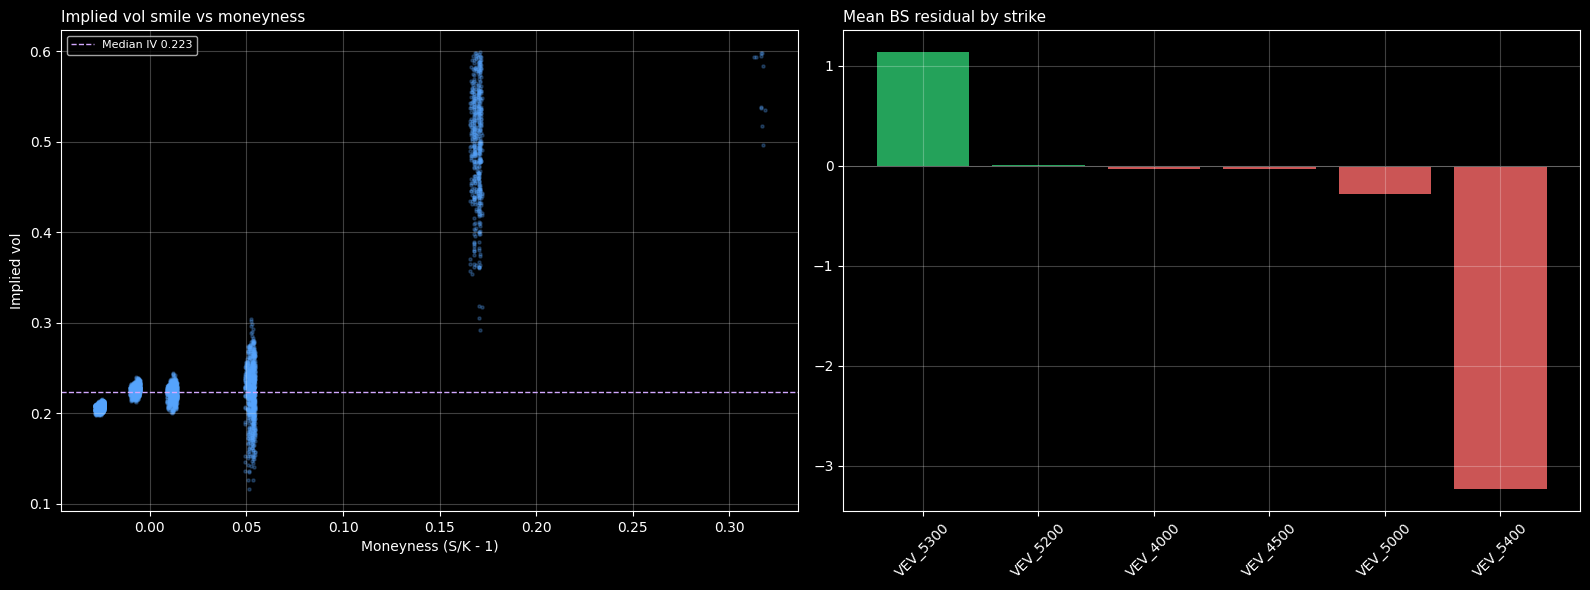

In [60]:
VE = mkt.get("VELVETFRUIT_EXTRACT", pd.DataFrame()).copy()
if VE.empty:
    print("No VEV market data found.")
else:
    ve_fair = VE["wall_mid"].ewm(span=40, adjust=False).mean()
    ve_trend = VE["mid_price"].ewm(span=10, adjust=False).mean() - VE["mid_price"].ewm(span=40, adjust=False).mean()
    T = tte_years(int(VE["timestamp"].iloc[0])) if "timestamp" in VE.columns else (5/365)

    # Step 1: estimate sigma from liquid strikes using current fair
    iv_rows = []
    for sym in CORE_VOUCHERS:
        if sym not in mkt:
            continue
        df = mkt[sym].copy()
        if df.empty:
            continue
        mids = 0.5 * (df["bid_price_1"] + df["ask_price_1"])
        for idx, m in enumerate(mids):
            S = float(ve_fair.iloc[min(idx, len(ve_fair)-1)])
            K = int(sym.split("_")[1])
            iv = implied_vol_from_price(float(m), S, K, T)
            if iv is not None and 0.05 <= iv <= 0.60:
                iv_rows.append({"symbol": sym, "timestamp": df["timestamp"].iloc[idx], "iv": iv, "moneyness": S / K - 1})

    iv_df = pd.DataFrame(iv_rows)
    if iv_df.empty:
        print("Not enough data to fit IV surface.")
    else:
        print("IV surface summary (core strikes):")
        display(iv_df.groupby("symbol").agg(iv_mean=("iv", "mean"), iv_std=("iv", "std"), mo_mean=("moneyness", "mean")))

        sigma_est = iv_df["iv"].median()
        print(f"Median implied vol estimate: {sigma_est:.4f}")

        # Residuals and strike ranking
        strike_summary = []
        for sym in CORE_VOUCHERS:
            if sym not in mkt:
                continue
            df = mkt[sym].copy()
            if df.empty:
                continue
            K = int(sym.split("_")[1])
            theo = []
            ivs = []
            resids = []
            deltas = []
            for i, row in df.iterrows():
                S = float(ve_fair.iloc[min(i, len(ve_fair)-1)])
                TT = tte_years(int(row["timestamp"]))
                mid = float(row["mid_price"])
                t = bs_call(S, K, TT, sigma_est)
                d = bs_delta(S, K, TT, sigma_est)
                theo.append(t)
                deltas.append(d)
                resids.append(mid - t)
                iv = implied_vol_from_price(mid, S, K, TT)
                ivs.append(iv)
            arr = pd.Series(resids)
            strike_summary.append({
                "symbol": sym,
                "mean_residual": arr.mean(),
                "std_residual": arr.std(),
                "hit_rate_over_0": (arr > 0).mean(),
                "delta_mean": np.nanmean(deltas),
                "delta_min": np.nanmin(deltas),
                "delta_max": np.nanmax(deltas),
                "approx_hedge_cost_ticks": np.nanmean(deltas) * (VE["spread"].mean() / 2.0),
                "option_half_spread": df["spread"].mean() / 2.0,
            })

        strike_df = pd.DataFrame(strike_summary).sort_values("mean_residual", ascending=False)
        display(strike_df)

        # Plot smile
        fig, ax = plt.subplots(1, 2, figsize=(16, 6))
        ax0, ax1 = ax
        ax0.scatter(iv_df["moneyness"], iv_df["iv"], s=5, alpha=0.25, color=C["spot"])
        ax0.axhline(sigma_est, color=C["ema"], lw=1.0, ls="--", label=f"Median IV {sigma_est:.3f}")
        ax0.set_title("Implied vol smile vs moneyness", loc="left", fontsize=11)
        ax0.set_xlabel("Moneyness (S/K - 1)")
        ax0.set_ylabel("Implied vol")
        ax0.grid(True, alpha=0.25)
        ax0.legend(fontsize=8)

        # Residuals by strike
        if not strike_df.empty:
            ax1.bar(strike_df["symbol"], strike_df["mean_residual"],
                    color=[C["buy"] if v > 0 else C["sell"] for v in strike_df["mean_residual"]], alpha=0.8)
            ax1.axhline(0, color="#666", lw=0.7)
            ax1.set_title("Mean BS residual by strike", loc="left", fontsize=11)
            ax1.tick_params(axis="x", rotation=45)
            ax1.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()

## 19 — Adjacent-strike relative value / vertical spread diagnostics

In [61]:
if "strike_df" not in globals() or strike_df.empty:
    print("No strike summary available yet.")
else:
    core = strike_df.sort_values("symbol").reset_index(drop=True).copy()
    core["strike"] = core["symbol"].str.split("_").str[1].astype(int)
    core = core.sort_values("strike").reset_index(drop=True)

    rel_rows = []
    for i in range(len(core)-1):
        a = core.iloc[i]
        b = core.iloc[i+1]
        rel_rows.append({
            "pair": f"{a['symbol']} vs {b['symbol']}",
            "strike_gap": int(b["strike"] - a["strike"]),
            "residual_gap": a["mean_residual"] - b["mean_residual"],
            "hedge_cost_gap": a["approx_hedge_cost_ticks"] - b["approx_hedge_cost_ticks"],
            "net_edge_gap": (a["mean_residual"] - a["approx_hedge_cost_ticks"]) - (b["mean_residual"] - b["approx_hedge_cost_ticks"]),
        })

    rel_df = pd.DataFrame(rel_rows)
    display(rel_df)

,pair,strike_gap,residual_gap,hedge_cost_gap,net_edge_gap
0,VEV_4000 vs VEV_4500,500,0.001008,6.740504e-07,0.001008
1,VEV_4500 vs VEV_5000,500,0.252314,1.237200e-01,0.128594
2,VEV_5000 vs VEV_5200,200,-0.286682,7.381023e-01,-1.024784
3,VEV_5200 vs VEV_5300,100,-1.131836,5.926101e-01,-1.724446
4,VEV_5300 vs VEV_5400,100,4.371358,5.150132e-01,3.856345


## 20 — Options trend sensitivity and residual persistence

In [62]:
if VE.empty:
    print("No VE data.")
else:
    ve_trend = VE["mid_price"].ewm(span=10, adjust=False).mean() - VE["mid_price"].ewm(span=40, adjust=False).mean()
    trend_frame = []
    for sym in CORE_VOUCHERS:
        if sym not in mkt:
            continue
        df = mkt[sym].copy()
        if df.empty:
            continue
        K = int(sym.split("_")[1])
        theo_series = []
        residuals = []
        for i, row in df.iterrows():
            S = float(VE["wall_mid"].ewm(span=40, adjust=False).mean().iloc[min(i, len(VE)-1)])
            T_i = tte_years(int(row["timestamp"]))
            theo = bs_call(S, K, T_i, sigma_est if "sigma_est" in globals() else 0.22)
            residuals.append(float(row["mid_price"]) - theo)
            theo_series.append(theo)
        res = pd.Series(residuals)
        vtrend = ve_trend.iloc[:len(res)]
        valid = ~(res.isna() | vtrend.isna())
        if valid.sum() < 20:
            continue
        trend_frame.append({
            "symbol": sym,
            "residual_mean": res.mean(),
            "residual_std": res.std(),
            "residual_ic_trend": res[valid].corr(vtrend[valid], method="spearman"),
            "residual_persistence": res.shift(1).corr(res, method="spearman"),
        })

    tf = pd.DataFrame(trend_frame).sort_values("residual_ic_trend", ascending=False)
    display(tf)

,symbol,residual_mean,residual_std,residual_ic_trend,residual_persistence
2,VEV_5000,-0.283705,2.890491,0.881576,0.926913
1,VEV_4500,-0.031391,3.060121,0.870187,0.905903
3,VEV_5200,0.002977,1.991180,0.867375,0.915845
0,VEV_4000,-0.030383,3.097799,0.867066,0.885625
4,VEV_5300,1.134812,1.280975,0.822713,0.900122
5,VEV_5400,-3.236546,0.603442,0.812305,0.877468


## 21 — Inventory accumulation vs PnL

In [63]:
for p in products:
    df = mkt[p].copy()
    pos_col = f"{p}_pos"
    if pos_col not in df.columns or "pnl" not in df.columns or df["pnl"].dropna().empty:
        continue
    print(f"\n═══ {p} — Inventory vs PnL ═══")
    pos = pd.to_numeric(df[pos_col], errors="coerce")
    pnl = pd.to_numeric(df["pnl"], errors="coerce")
    valid = ~(pos.isna() | pnl.isna())
    if valid.sum() < 20:
        continue
    corr = pos[valid].corr(pnl[valid], method="spearman")
    print(f"  Spearman corr(position, pnl): {corr:+.4f}")
    print(f"  Mean |position|/limit       : {np.nanmean(np.abs(pos)) / (300 if p.startswith('VEV_') else 200):.3f}")

## 22 — Market trades / execution details + cumulative fill tracker

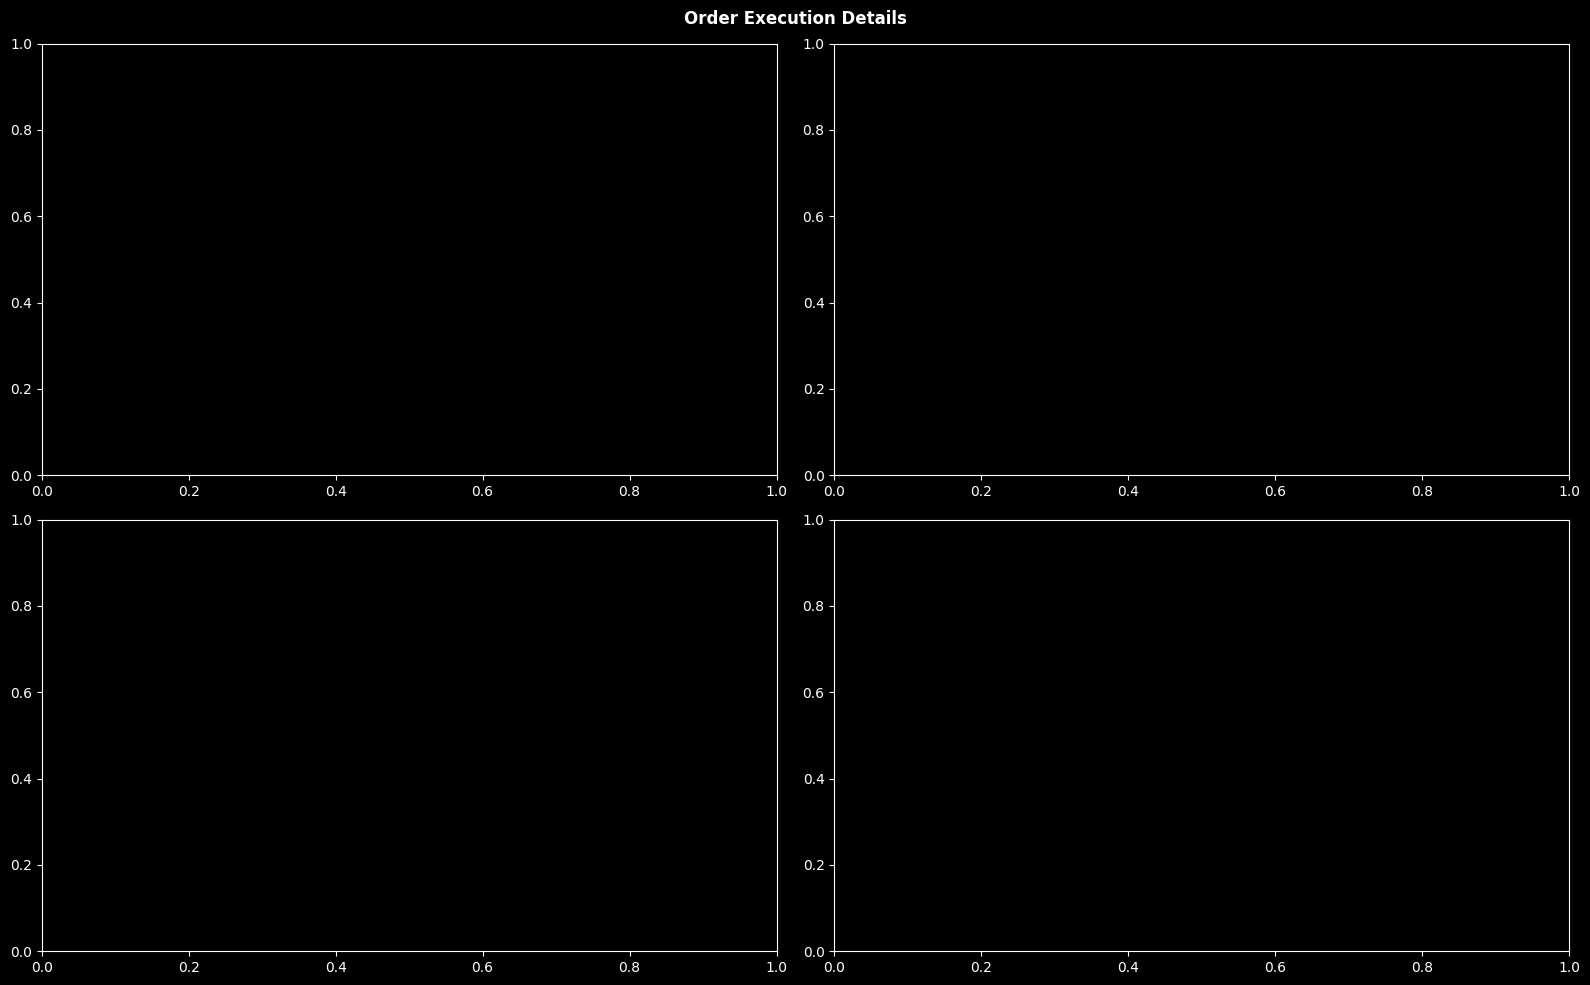

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Order Execution Details", fontsize=12, fontweight="bold")

if not our_trades.empty and "timestamp" in our_trades.columns:
    ax1, ax2, ax3, ax4 = axes.flatten()

    # cumulative fills per product
    for p in products:
        pts = our_trades[our_trades["symbol"].astype(str) == p].sort_values("timestamp")
        if pts.empty:
            continue
        pts = pts.copy()
        pts["signed_qty"] = np.where(pts["side"] == "BUY", pts["abs_qty"], -pts["abs_qty"])
        pts["cum_qty"] = pts["signed_qty"].cumsum()
        ax1.step(pts["timestamp"], pts["cum_qty"], where="post", lw=1.4, label=p)
    ax1.set_title("Cumulative filled quantity", loc="left", fontsize=10)
    ax1.grid(True, alpha=0.25)
    ax1.legend(fontsize=8)

    # fill price distributions
    for p in products:
        pts = our_trades[our_trades["symbol"].astype(str) == p]
        if pts.empty:
            continue
        buys = pts[pts["side"] == "BUY"]
        sells = pts[pts["side"] == "SELL"]
        if not buys.empty:
            ax2.hist(buys["price"], bins=20, alpha=0.35, density=True, color=C["buy"], label=f"{p} BUY")
        if not sells.empty:
            ax2.hist(sells["price"], bins=20, alpha=0.35, density=True, color=C["sell"], label=f"{p} SELL")
    ax2.set_title("Fill price distribution", loc="left", fontsize=10)
    ax2.grid(True, alpha=0.25)
    ax2.legend(fontsize=7)

    # PnL by product
    finals = []
    for p in products:
        df = mkt[p]
        if "pnl" not in df.columns or df["pnl"].dropna().empty:
            continue
        finals.append((p, float(df["pnl"].dropna().iloc[-1])))
    if finals:
        finals = sorted(finals, key=lambda x: x[1], reverse=True)
        ax3.bar([x[0] for x in finals], [x[1] for x in finals],
                color=[C["buy"] if x[1] >= 0 else C["sell"] for x in finals], alpha=0.8)
        ax3.axhline(0, color="#666", lw=0.7)
        ax3.set_title("Final PnL by product", loc="left", fontsize=10)
        ax3.tick_params(axis="x", rotation=45)
        ax3.grid(True, alpha=0.25)

    # avg buy vs sell prices
    rows = []
    for p in products:
        pts = our_trades[our_trades["symbol"].astype(str) == p]
        if pts.empty:
            continue
        buys = pts[pts["side"] == "BUY"]
        sells = pts[pts["side"] == "SELL"]
        if buys.empty or sells.empty:
            continue
        ab = np.average(buys["price"], weights=buys["abs_qty"])
        as_ = np.average(sells["price"], weights=sells["abs_qty"])
        rows.append((p, ab, as_, as_ - ab))
    if rows:
        r = pd.DataFrame(rows, columns=["product", "avg_buy", "avg_sell", "round_trip_unit_pnl"])
        display(r.sort_values("round_trip_unit_pnl", ascending=False))
        ax4.bar(r["product"], r["round_trip_unit_pnl"], color=[C["buy"] if v > 0 else C["sell"] for v in r["round_trip_unit_pnl"]], alpha=0.8)
        ax4.axhline(0, color="#666", lw=0.7)
        ax4.set_title("Round-trip unit PnL", loc="left", fontsize=10)
        ax4.tick_params(axis="x", rotation=45)
        ax4.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 23 — Leaderboard-style performance metrics

In [65]:
METRICS = {
    "total_profit": result_profit,
    "per_product": {},
    "avg_fill": np.nan,
    "max_drawdown": np.nan,
    "recovery_ratio": np.nan,
    "spot_products": spot_products,
    "voucher_products": voucher_products,
}

fill_counts = []
for p, df in mkt.items():
    pm = {}
    if "pnl" in df.columns and df["pnl"].dropna().any():
        pnl = pd.to_numeric(df["pnl"], errors="coerce").fillna(method="ffill").fillna(0.0)
        dd = drawdown_series(pnl)
        pm["pnl"] = float(pnl.iloc[-1])
        pm["max_drawdown"] = float(dd.max()) if len(dd) else np.nan
        pm["recovery"] = float(pnl.iloc[-1] / (dd.max() + 1e-9)) if len(dd) and dd.max() > 0 else np.nan
    pm["mean_spread"] = float(df["spread"].mean())
    pm["mean_imbalance"] = float(df["imbalance"].mean())
    pm["autocorr_1"] = float(autocorr(df["mid_price"], 1)) if len(df) > 3 else np.nan
    pm["hurst"] = float(hurst_exponent(df["mid_price"])) if len(df) > 10 else np.nan

    pts = our_trades[our_trades["symbol"].astype(str) == p] if not our_trades.empty else pd.DataFrame()
    if not pts.empty:
        fill_counts.append(len(pts))
        pm["our_fills"] = len(pts)
        pm["buy_fills"] = int((pts["side"] == "BUY").sum())
        pm["sell_fills"] = int((pts["side"] == "SELL").sum())
    METRICS["per_product"][p] = pm

if fill_counts:
    METRICS["avg_fill"] = float(np.mean(fill_counts))

if mkt:
    all_pnl = []
    for p, df in mkt.items():
        if "pnl" in df.columns and df["pnl"].dropna().any():
            pnl = pd.to_numeric(df["pnl"], errors="coerce").fillna(method="ffill").fillna(0.0)
            all_pnl.append(pnl)
    if all_pnl:
        stacked = pd.concat(all_pnl, axis=1).sum(axis=1)
        dd = drawdown_series(stacked)
        METRICS["max_drawdown"] = float(dd.max())
        METRICS["recovery_ratio"] = float(stacked.iloc[-1] / (dd.max() + 1e-9)) if len(dd) and dd.max() > 0 else np.nan

print("═══════════════════════════════════════════════════════════════════")
print("  SUMMARY METRICS")
print("═══════════════════════════════════════════════════════════════════")
print(f"Total profit reported : {METRICS['total_profit']:,.4f}")
print(f"Average fills/product  : {METRICS['avg_fill']:.2f}")
print(f"Total max drawdown    : {METRICS['max_drawdown']:.4f}")
print(f"Recovery ratio        : {METRICS['recovery_ratio']:.4f}")
display(pd.DataFrame(METRICS["per_product"]).T.sort_values("pnl", ascending=False) if any("pnl" in v for v in METRICS["per_product"].values()) else pd.DataFrame(METRICS["per_product"]).T)

═══════════════════════════════════════════════════════════════════
  SUMMARY METRICS
═══════════════════════════════════════════════════════════════════
Total profit reported : 15,369.8334
Average fills/product  : nan
Total max drawdown    : 23231.6278
Recovery ratio        : 0.6616


,pnl,max_drawdown,recovery,mean_spread,mean_imbalance,autocorr_1,hurst
HYDROGEL_PACK,11520.000000,11657.625000,0.988194,15.645,-0.000972,0.997064,0.498015
VELVETFRUIT_EXTRACT,2269.906250,2688.500000,0.844302,4.983,0.000456,0.988086,0.496486
VEV_5100,1172.292969,8644.433594,0.135612,4.444,-0.000003,0.990960,0.515595
VEV_5000,238.609375,4075.176758,0.058552,6.231,-0.000003,0.990556,0.508879
VEV_5300,183.583008,4106.527344,0.044705,2.171,0.000032,0.988499,0.469264
VEV_5400,50.876099,154.547455,0.329194,1.419,-0.000042,0.984091,0.423983
VEV_4000,-2.690430,149.695312,-0.017973,20.973,0.000052,0.982334,0.456597
VEV_4500,-2.690430,149.695312,-0.017973,16.081,-0.000003,0.986502,0.480298
VEV_5500,-18.791748,818.283813,-0.022965,1.169,-0.000071,0.963465,0.332724
VEV_5200,-41.261719,6648.783203,-0.006206,2.984,-0.000003,0.988912,0.495973


## 24 — Round 3 strategy translation table

In [66]:
strategy_rows = []

for p in spot_products:
    df = mkt[p]
    ic = df["imbalance"].corr(df["mid_chg"].shift(-1), method="spearman")
    strategy_rows.append({
        "product": p,
        "role": "Spot / reference",
        "best_estimator": "wall_mid + OBI + mild trend",
        "signal": "Use order-flow pressure + adaptive fair value",
        "risk_rule": "Strong-trend regime => reduce fading / one-sided bias",
        "evidence": f"OBI IC={ic:+.4f}",
    })

if "strike_df" in globals() and not strike_df.empty:
    for _, r in strike_df.iterrows():
        sym = r["symbol"]
        strategy_rows.append({
            "product": sym,
            "role": "Voucher",
            "best_estimator": "BS + smile residual",
            "signal": "Trade only when residual persists and hedge cost is covered",
            "risk_rule": f"edge={r['mean_residual']:+.2f}, hedge_cost≈{r['approx_hedge_cost_ticks']:.2f}",
            "evidence": f"delta≈{r['delta_mean']:.2f}",
        })

strategy_df = pd.DataFrame(strategy_rows)
display(strategy_df)

,product,role,best_estimator,signal,risk_rule,evidence
0,HYDROGEL_PACK,Spot / reference,wall_mid + OBI + mild trend,Use order-flow pressure + adaptive fair value,Strong-trend regime => reduce fading / one-sid...,OBI IC=-0.3042
1,VELVETFRUIT_EXTRACT,Spot / reference,wall_mid + OBI + mild trend,Use order-flow pressure + adaptive fair value,Strong-trend regime => reduce fading / one-sid...,OBI IC=-0.3369
2,VEV_5300,Voucher,BS + smile residual,Trade only when residual persists and hedge co...,"edge=+1.13, hedge_cost≈1.04",delta≈0.42
3,VEV_5200,Voucher,BS + smile residual,Trade only when residual persists and hedge co...,"edge=+0.00, hedge_cost≈1.63",delta≈0.65
4,VEV_4000,Voucher,BS + smile residual,Trade only when residual persists and hedge co...,"edge=-0.03, hedge_cost≈2.49",delta≈1.00
5,VEV_4500,Voucher,BS + smile residual,Trade only when residual persists and hedge co...,"edge=-0.03, hedge_cost≈2.49",delta≈1.00
6,VEV_5000,Voucher,BS + smile residual,Trade only when residual persists and hedge co...,"edge=-0.28, hedge_cost≈2.37",delta≈0.95
7,VEV_5400,Voucher,BS + smile residual,Trade only when residual persists and hedge co...,"edge=-3.24, hedge_cost≈0.52",delta≈0.21


## 25 — Improvement roadmap from all metrics combined

In [67]:
print("═══════════════════════════════════════════════════════════════════")
print("  IMPROVEMENT ROADMAP — Round 3")
print("═══════════════════════════════════════════════════════════════════")

roadmap = []

# 1) Identify spot regimes
for p in spot_products:
    df = mkt[p]
    ic = df["imbalance"].corr(df["mid_chg"].shift(-1), method="spearman")
    if abs(ic) > 0.03:
        roadmap.append((1, f"{p}: add OBI-based quote skew", ic,
                        "Shift bid/ask by 1 tick in the direction of imbalance when spread is tight and trend is weak."))

# 2) Options strike selection from residuals
if "strike_df" in globals() and not strike_df.empty:
    for _, r in strike_df.iterrows():
        net_edge = r["mean_residual"] - r["approx_hedge_cost_ticks"]
        if net_edge > 0:
            roadmap.append((1, f"{r['symbol']}: candidate long/short edge", net_edge,
                            "Trade only if the sign persists across timestamps; size by edge magnitude, not by habit."))
        else:
            roadmap.append((2, f"{r['symbol']}: likely skip or tiny size", net_edge,
                            "Residual edge does not survive estimated hedge cost."))
# 3) Toxicity
if not toxicity.empty:
    tox_sum = toxicity.groupby(["product", "horizon"])["impact"].mean().reset_index()
    for _, row in tox_sum.iterrows():
        if row["impact"] < 0:
            roadmap.append((1, f"{row['product']}: adverse selection at horizon {int(row['horizon'])}", row["impact"],
                            "Widen passive edge, reduce quote size, and avoid being hit on the toxic side."))

roadmap.sort(key=lambda x: x[0])
for prio, name, metric, fix in roadmap[:30]:
    tag = "🔴 CRITICAL" if prio == 1 else "🟡 IMPORTANT"
    print(f"{tag}  {name}")
    print(f"   Metric value : {metric:.4f}")
    print(f"   Suggested fix: {fix}\n")

if not roadmap:
    print("No obvious issues found. Focus on parameter tuning and strike-level sizing.")
print("═══════════════════════════════════════════════════════════════════")
print("Validate any change on multiple logs before trusting it.")
print("Round 3 usually rewards simple stable edge more than clever one-off trades.")

═══════════════════════════════════════════════════════════════════
  IMPROVEMENT ROADMAP — Round 3
═══════════════════════════════════════════════════════════════════
🔴 CRITICAL  HYDROGEL_PACK: add OBI-based quote skew
   Metric value : -0.3042
   Suggested fix: Shift bid/ask by 1 tick in the direction of imbalance when spread is tight and trend is weak.

🔴 CRITICAL  VELVETFRUIT_EXTRACT: add OBI-based quote skew
   Metric value : -0.3369
   Suggested fix: Shift bid/ask by 1 tick in the direction of imbalance when spread is tight and trend is weak.

🔴 CRITICAL  VEV_5300: candidate long/short edge
   Metric value : 0.0977
   Suggested fix: Trade only if the sign persists across timestamps; size by edge magnitude, not by habit.

🟡 IMPORTANT  VEV_5200: likely skip or tiny size
   Metric value : -1.6267
   Suggested fix: Residual edge does not survive estimated hedge cost.

🟡 IMPORTANT  VEV_4000: likely skip or tiny size
   Metric value : -2.5219
   Suggested fix: Residual edge does not su